# NSSC 2026 Mars HiRISE anomaly detection

This notebook records three from-scratch autoencoder experiments, latent Isolation Forest scoring, distribution-based thresholding, source metadata analysis and reconstruction hypotheses. It uses no pretrained weights or external image pretraining. **Higher novelty score means greater anomalousness.** Hidden anomaly labels and the payload count are unavailable, so no detection-accuracy claim is made.

The executed output cells document the delivered runs. To reproduce on Colab or Kaggle, select a GPU and provide the original outer dataset ZIP (a private input on Kaggle). All model modules are embedded. Fresh execution trains missing runs and reuses completed ones. GPU numerical differences may change scores; inspect regenerated outputs before reusing recorded physical hypotheses. No cloud compute is purchased and no data is published by this notebook.


In [1]:
from pathlib import Path
import os, sys, json, importlib.util, subprocess
if Path('/kaggle/working').exists(): ROOT=Path('/kaggle/working/mars_project')
elif Path('/content').exists(): ROOT=Path('/content/mars_project')
else:
    ROOT=Path.cwd()
    if ROOT.name=='notebooks':ROOT=ROOT.parent
ROOT.mkdir(parents=True,exist_ok=True);os.chdir(ROOT);sys.path.insert(0,str(ROOT))
required={'numpy':'numpy','pandas':'pandas','PIL':'Pillow','scipy':'scipy','sklearn':'scikit-learn','matplotlib':'matplotlib','statsmodels':'statsmodels','torch':'torch'}
missing=[v for k,v in required.items() if importlib.util.find_spec(k) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
import torch,numpy as np,pandas as pd,matplotlib.pyplot as plt
from IPython.display import display,Image,Markdown
print('Project:',ROOT,'| PyTorch:',torch.__version__,'| CUDA:',torch.cuda.is_available())
if torch.cuda.is_available():print(torch.cuda.get_device_name())


Project: C:\Users\deves\OneDrive\Desktop\Projects\IIT_KGP_DA_PS | PyTorch: 2.13.0+cpu | CUDA: False


In [2]:
EMBEDDED_FILES = {
    "mars_anomaly/__init__.py": '"""From-scratch HiRISE autoencoder and latent novelty pipeline."""\n',
    "mars_anomaly/data.py": 'from pathlib import Path\nimport io\nfrom zipfile import ZipFile\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom PIL import Image\nfrom torch.utils.data import Dataset\nfrom .preprocessing import preprocess_array,MODES\n\n\ndef prepare_archive(archive, destination):\n    """Extract only the known dataset structure, never arbitrary archive paths."""\n    destination = Path(destination)\n    destination.mkdir(parents=True, exist_ok=True)\n    with ZipFile(archive) as outer:\n        for name in (\'crop_metadata_index.csv\', \'source_image_metadata.csv\'):\n            (destination / name).write_bytes(outer.read(\'DATASETS/\' + name))\n        payload = outer.read(\'DATASETS/images.zip\')\n    expected = set(pd.read_csv(destination / \'crop_metadata_index.csv\').filename)\n    seen = set()\n    image_dir = destination / \'images\'\n    image_dir.mkdir(exist_ok=True)\n    with ZipFile(io.BytesIO(payload)) as inner:\n        for entry in inner.infolist():\n            if entry.is_dir():\n                continue\n            name = Path(entry.filename).name\n            if name not in expected or name in seen:\n                raise ValueError(f\'Unexpected or duplicate image: {name}\')\n            seen.add(name)\n            target = image_dir / name\n            if not target.exists():\n                target.write_bytes(inner.read(entry))\n    if seen != expected:\n        raise ValueError(\'Archive and crop index do not match\')\n    return destination\n\n\ndef load_manifest(data_dir, seed=2026):\n    data_dir = Path(data_dir)\n    crops = pd.read_csv(data_dir / \'crop_metadata_index.csv\')\n    sources = pd.read_csv(data_dir / \'source_image_metadata.csv\')\n    if not crops.filename.is_unique or not sources.source_image_id.is_unique:\n        raise ValueError(\'Duplicate metadata join keys\')\n    frame = crops.merge(sources, on=\'source_image_id\', how=\'left\', validate=\'many_to_one\')\n    if frame.isna().any().any():\n        raise ValueError(\'Missing metadata\')\n    groups = np.array(sorted(frame.source_image_id.unique()))\n    if len(groups) < 10:\n        raise ValueError(\'At least 10 source groups required\')\n    np.random.default_rng(seed).shuffle(groups)\n    n_train, n_val = int(.7 * len(groups)), int(.15 * len(groups))\n    assignment = {g: (\'train\' if i < n_train else \'validation\' if i < n_train+n_val else \'calibration\') for i,g in enumerate(groups)}\n    frame[\'split\'] = frame.source_image_id.map(assignment)\n    frame[\'path\'] = [str(data_dir / \'images\' / name) for name in frame.filename]\n    if not all(Path(p).is_file() for p in frame.path):\n        raise FileNotFoundError(\'Some indexed image files are missing\')\n    return frame\n\n\nclass CropDataset(Dataset):\n    def __init__(self, frame, preprocessing=\'raw\'):\n        self.frame = frame.reset_index(drop=True)\n        if preprocessing not in MODES:raise ValueError(\'Unknown preprocessing mode\')\n        self.preprocessing=preprocessing\n\n    def __len__(self):\n        return len(self.frame)\n\n    def __getitem__(self, index):\n        row = self.frame.iloc[index]\n        with Image.open(row.path) as image:\n            if image.mode != \'L\' or image.size != (227,227):\n                raise ValueError(f\'Unexpected image contract: {row.filename}\')\n            array = np.array(image, dtype=np.float32) / 255.\n        return torch.from_numpy(preprocess_array(array,self.preprocessing)).unsqueeze(0), index\n',
    "mars_anomaly/evaluate.py": "import argparse\nimport json\nfrom pathlib import Path\nimport joblib\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom torch.utils.data import DataLoader\nfrom sklearn.ensemble import IsolationForest\nfrom sklearn.decomposition import PCA\nfrom sklearn.manifold import TSNE\nfrom scipy.stats import spearmanr\nfrom .data import load_manifest,CropDataset\nfrom .model import ConvAutoencoder\nfrom .threshold import calibrate,select_flagged\nfrom .visualize import score_plots,heatmap_panel\n\n\ndef evaluate(data_dir,run_dir,bootstrap=100,projection=True,allow_smoke=False,method='adjusted_boxplot',trees=400):\n    run_dir = Path(run_dir)\n    checkpoint = torch.load(run_dir/'best.pt',map_location='cpu',weights_only=False)\n    config = checkpoint['config']\n    if method!='adjusted_boxplot' or trees!=400:\n        run_dir=run_dir/(method+(f'_trees{trees}' if trees!=400 else ''))\n        run_dir.mkdir(parents=True,exist_ok=True)\n    if config['max_batches'] and not allow_smoke:\n        raise ValueError('Smoke checkpoint cannot produce competition results')\n    torch.set_num_threads(4)\n    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')\n    model = ConvAutoencoder(config['latent_dim']).to(device)\n    model.load_state_dict(checkpoint['model']);model.eval()\n    frame = load_manifest(data_dir,config.get('split_seed',config['seed']))\n    preprocessing=config.get('preprocessing','raw')\n    loader = DataLoader(CropDataset(frame,preprocessing),batch_size=config['batch_size'],num_workers=0)\n    latents,errors = [],[]\n    with torch.no_grad():\n        for x,_ in loader:\n            x = x.to(device)\n            reconstruction,z = model(x)\n            latents.append(z.cpu().numpy())\n            errors.extend((x-reconstruction).square().mean((1,2,3)).cpu().tolist())\n    z = np.concatenate(latents)\n    np.save(run_dir/'latents.npy',z)\n    np.save(run_dir/'latent_filenames.npy',frame.filename.to_numpy(dtype=str))\n    train = frame.split.eq('train').to_numpy()\n    calibration_mask = frame.split.eq('calibration').to_numpy()\n    forest = IsolationForest(n_estimators=trees,max_samples=256,contamination='auto',random_state=config['seed'],n_jobs=2)\n    forest.fit(z[train])\n    frame['novelty_score'] = -forest.score_samples(z)\n    frame['reconstruction_mse'] = errors\n    calibration = calibrate(frame.loc[calibration_mask,'novelty_score'],frame.loc[calibration_mask,'source_image_id'],bootstrap,config['seed'],method)\n    frame['flagged'] = frame.novelty_score>calibration['threshold']\n    boot = np.asarray(calibration['bootstrap_thresholds'])\n    frame['threshold_bootstrap_flag_frequency'] = (frame.novelty_score.to_numpy()[:,None]>boot[None,:]).mean(1)\n    # Independent forests assess Monte Carlo rank variability, not hidden-label accuracy.\n    stability = []\n    for seed in (config['seed']+1,config['seed']+2):\n        other = IsolationForest(n_estimators=trees,max_samples=256,contamination='auto',random_state=seed,n_jobs=2).fit(z[train])\n        other_scores = -other.score_samples(z)\n        from .threshold import upper_fence,mixture_fence\n        boundary = (upper_fence(other_scores[calibration_mask]) if method=='adjusted_boxplot' else mixture_fence(other_scores[calibration_mask],config['seed']))['threshold']\n        other_flags = other_scores>boundary\n        primary_flags = frame.flagged.to_numpy()\n        union = np.count_nonzero(primary_flags|other_flags)\n        stability.append({'seed':seed,'spearman':float(spearmanr(frame.novelty_score,other_scores).statistic),'flag_count':int(other_flags.sum()),'threshold':boundary,'flag_jaccard':float(np.count_nonzero(primary_flags&other_flags)/union) if union else None})\n    covariance = np.cov(z[train],rowvar=False)\n    eigenvalues = np.linalg.eigvalsh(covariance).clip(0)\n    proportions = eigenvalues/max(eigenvalues.sum(),1e-12)\n    effective_rank = float(np.exp(-np.sum(proportions*np.log(proportions+1e-12))))\n    diagnostics = {'effective_rank':effective_rank,'latent_dimensions':z.shape[1],'latent_variance':z[train].var(0).tolist(),'forest_seed_stability':stability,'flagged_total':int(frame.flagged.sum()),'flagged_by_split':frame.groupby('split').flagged.agg(['sum','count','mean']).to_dict(),'smoke_checkpoint':bool(config['max_batches']),'threshold_exceeds_maximum':bool(calibration['threshold']>frame.novelty_score.max())}\n    diagnostics['n_estimators']=trees\n    diagnostics['preprocessing']=preprocessing\n    diagnostics['reconstruction_domain']='raw intensity / 255' if preprocessing=='raw' else preprocessing+' standardized input'\n    if method=='mixture_three_sigma':\n        from scipy.stats import norm\n        means=np.array(calibration['means']);std=np.array(calibration['std']);weights=np.array(calibration['weights'])\n        heldout=np.sort(frame.loc[frame.split.eq('validation'),'novelty_score'])\n        cdf=np.sum(weights*norm.cdf((heldout[:,None]-means)/std),axis=1)\n        n=len(heldout)\n        diagnostics['validation_cdf_max_distance']=float(max(np.max(np.arange(1,n+1)/n-cdf),np.max(cdf-np.arange(n)/n)))\n        diagnostics['validation_cdf_note']='Descriptive held-out density-fit diagnostic; correlated sources preclude an ordinary IID KS p-value.'\n    (run_dir/'calibration.json').write_text(json.dumps(calibration,indent=2))\n    (run_dir/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2))\n    frame.drop(columns='path').to_csv(run_dir/'novelty_scores.csv',index=False)\n    joblib.dump(forest,run_dir/'isolation_forest.joblib')\n    score_plots(frame,calibration,run_dir/'score_distribution.png')\n    source_summary = frame.groupby('source_image_id').agg(crops=('filename','size'),flagged=('flagged','sum'),mean_novelty=('novelty_score','mean'),latitude=('latitude','first'),longitude=('longitude','first'),sun_angle=('sun_angle','first'),season=('season','first'),resolution=('resolution','first'))\n    source_summary['flag_rate'] = source_summary.flagged/source_summary.crops\n    source_summary.to_csv(run_dir/'source_summary.csv')\n    for column in ('season','resolution','longitude'):\n        crop_summary = frame.groupby(column).flagged.agg(['count','sum','mean'])\n        equal_source = source_summary.groupby(column).flag_rate.mean()\n        crop_summary['equal_source_mean_flag_rate'] = equal_source\n        crop_summary.to_csv(run_dir/f'metadata_{column}.csv')\n    selected = select_flagged(frame,calibration['threshold'])\n    selected.drop(columns='path').to_csv(run_dir/'selected_for_interpretation.csv',index=False)\n    for _,row in selected.iterrows():\n        x,_ = CropDataset(pd.DataFrame([row]),preprocessing)[0]\n        with torch.no_grad(): rec = model(x[None].to(device))[0][0,0].cpu().numpy()\n        if preprocessing=='raw':\n            heatmap_panel(x[0].numpy(),rec,row,calibration['threshold'],run_dir/f'heatmap_{Path(row.filename).stem}.png')\n        else:\n            from .visualize import standardized_heatmap_panel\n            raw,_=CropDataset(pd.DataFrame([row]))[0]\n            standardized_heatmap_panel(raw[0].numpy(),x[0].numpy(),rec,row,calibration['threshold'],run_dir/f'heatmap_{Path(row.filename).stem}.png',preprocessing)\n    if projection:\n        import matplotlib.pyplot as plt\n        # Standardization affects visualization only; the forest uses the original latent.\n        scale = z[train].std(0).clip(1e-6)\n        standardized = (z-z[train].mean(0))/scale\n        reduced = PCA(n_components=min(50,z.shape[1]),random_state=config['seed']).fit_transform(standardized)\n        for perplexity in (30,70):\n            xy = TSNE(n_components=2,perplexity=perplexity,init='pca',learning_rate='auto',random_state=config['seed'],max_iter=1000).fit_transform(reduced)\n            pd.DataFrame({'filename':frame.filename,'x':xy[:,0],'y':xy[:,1]}).to_csv(run_dir/f'tsne_{perplexity}.csv',index=False)\n            fig,axes = plt.subplots(1,3,figsize=(15,4))\n            for ax,values,title in zip(axes,[frame.novelty_score,frame.sun_angle,pd.Categorical(frame.source_image_id).codes],['Novelty score','Sun angle as supplied','Source ID (categorical colors)']):\n                points = ax.scatter(xy[:,0],xy[:,1],c=values,s=3,cmap='viridis',rasterized=True)\n                fig.colorbar(points,ax=ax);ax.set_title(title);ax.set_xticks([]);ax.set_yticks([])\n            fig.suptitle(f't-SNE perplexity {perplexity}; qualitative projection, not geological labels')\n            fig.tight_layout();fig.savefig(run_dir/f'tsne_{perplexity}.png',dpi=160);plt.close(fig)\n    print(json.dumps({k:v for k,v in diagnostics.items() if k!='latent_variance'},indent=2),flush=True)\n    return frame,calibration,diagnostics\n\n\ndef main():\n    parser=argparse.ArgumentParser()\n    parser.add_argument('--data',default='data');parser.add_argument('--run',required=True)\n    parser.add_argument('--bootstrap',type=int,default=100);parser.add_argument('--no-projection',action='store_true')\n    parser.add_argument('--method',choices=['adjusted_boxplot','mixture_three_sigma'],default='adjusted_boxplot')\n    parser.add_argument('--trees',type=int,default=400)\n    args=parser.parse_args()\n    evaluate(args.data,args.run,args.bootstrap,not args.no_projection,method=args.method,trees=args.trees)\n\nif __name__=='__main__': main()\n",
    "mars_anomaly/model.py": 'import torch\nfrom torch import nn\nfrom torch.nn import functional as F\n\n\nclass ConvAutoencoder(nn.Module):\n    """No pretrained weights, external features, or bottleneck bypass."""\n    def __init__(self, latent_dim=128):\n        super().__init__()\n        channels = (1,16,32,64,96,128)\n        blocks = []\n        for cin,cout in zip(channels[:-1],channels[1:]):\n            blocks.extend([nn.Conv2d(cin,cout,3,stride=2,padding=1), nn.GroupNorm(8,cout), nn.SiLU()])\n        self.encoder = nn.Sequential(*blocks)\n        self.to_latent = nn.Linear(128*8*8, latent_dim)\n        self.from_latent = nn.Linear(latent_dim,128*8*8)\n        self.decoder = nn.ModuleList()\n        for cin,cout in zip((128,96,64,32,16),(96,64,32,16,1)):\n            layers = [nn.Conv2d(cin,cout,3,padding=1)]\n            layers += [nn.Sigmoid()] if cout == 1 else [nn.GroupNorm(8,cout),nn.SiLU()]\n            self.decoder.append(nn.Sequential(*layers))\n\n    def encode(self,x):\n        return self.to_latent(self.encoder(x).flatten(1))\n\n    def decode(self,z):\n        x = self.from_latent(z).reshape(-1,128,8,8)\n        for size,block in zip((15,29,57,114,227),self.decoder):\n            x = block(F.interpolate(x,size=(size,size),mode=\'bilinear\',align_corners=False))\n        return x\n\n    def forward(self,x):\n        z = self.encode(x)\n        return self.decode(z),z\n\n\ndef ssim_per_image(x,y):\n    """11x11 Gaussian-window SSIM, sigma 1.5, data range 1, valid windows."""\n    x,y = x.float(),y.float()\n    coords = torch.arange(11,device=x.device,dtype=x.dtype)-5\n    weights = torch.exp(-coords.square()/(2*1.5**2))\n    weights = weights / weights.sum()\n    # Separable filters compute the same Gaussian window with less work.\n    def smooth(a):\n        a = F.conv2d(a,weights.reshape(1,1,1,11))\n        return F.conv2d(a,weights.reshape(1,1,11,1))\n    mx,my = smooth(x),smooth(y)\n    vx = (smooth(x*x)-mx*mx).clamp_min(0)\n    vy = (smooth(y*y)-my*my).clamp_min(0)\n    cov = smooth(x*y)-mx*my\n    result = ((2*mx*my+.01**2)*(2*cov+.03**2))/((mx*mx+my*my+.01**2)*(vx+vy+.03**2))\n    return result.mean((1,2,3))\n\n\ndef loss_components(x,reconstruction,structural_weight=0.,gradient_weight=0.):\n    x,reconstruction = x.float(),reconstruction.float()\n    mse = (x-reconstruction).square().mean((1,2,3))\n    with torch.set_grad_enabled(torch.is_grad_enabled() and structural_weight>0):\n        ssim = ssim_per_image(x,reconstruction)\n    dx = (x[:,:,:,1:]-x[:,:,:,:-1])-(reconstruction[:,:,:,1:]-reconstruction[:,:,:,:-1])\n    dy = (x[:,:,1:,:]-x[:,:,:-1,:])-(reconstruction[:,:,1:,:]-reconstruction[:,:,:-1,:])\n    gradient = .5*(dx.abs().mean((1,2,3))+dy.abs().mean((1,2,3)))\n    loss = (1-structural_weight)*mse\n    if structural_weight: loss = loss+structural_weight*(1-ssim)\n    if gradient_weight: loss = loss+gradient_weight*gradient\n    return {\'loss\':loss.mean(),\'mse\':mse.mean(),\'ssim\':ssim.mean(),\'gradient\':gradient.mean()}\n',
    "mars_anomaly/preprocessing.py": '"""Explicit, per-image photometric ablations; no fitted dataset statistics."""\nimport numpy as np\nfrom scipy.ndimage import label, binary_dilation, distance_transform_edt\n\nMODES=(\'raw\',\'contrast\',\'footprint\',\'border_fill\')\n\n\ndef border_zero_mask(array):\n    regions,_=label(array==0)\n    border=np.unique(np.concatenate([regions[0],regions[-1],regions[:,0],regions[:,-1]]))\n    return np.isin(regions,border[border!=0])\n\n\ndef border_near_black_mask(array):\n    """Fixed JPEG-tolerant border heuristic; not a ground-truth validity mask."""\n    regions, _ = label(array <= 4/255)\n    edge = np.unique(np.concatenate([regions[0],regions[-1],regions[:,0],regions[:,-1]]))\n    mask = np.isin(regions, edge[edge != 0])\n    return binary_dilation(mask, iterations=2) if mask.any() else mask\n\n\ndef preprocess_array(array,mode=\'raw\'):\n    if mode not in MODES:raise ValueError(f\'Unknown preprocessing: {mode}\')\n    x=np.asarray(array,dtype=np.float32)\n    if x.ndim!=2 or not np.isfinite(x).all():raise ValueError(\'Expected finite 2D image\')\n    if mode==\'raw\':return x\n    excluded=(border_near_black_mask(x) if mode==\'border_fill\' else\n              border_zero_mask(x) if mode==\'footprint\' else np.zeros(x.shape,dtype=bool))\n    values=x[~excluded]\n    if not len(values):return np.full_like(x,.5)\n    mean=float(values.mean());std=max(float(values.std()),1/255)\n    result=np.clip(.5+.15*(x-mean)/std,0,1).astype(np.float32)\n    if mode==\'border_fill\' and excluded.any():\n        nearest=distance_transform_edt(excluded,return_distances=False,return_indices=True)\n        result[excluded]=result[tuple(nearest[:,excluded])]\n    else:\n        result[excluded]=.5\n    return result\n',
    "mars_anomaly/threshold.py": 'import numpy as np\nfrom statsmodels.stats.stattools import medcouple\n\n\ndef mixture_fence(scores,seed=2026):\n    """Envelope beyond every fitted score population; no contamination fraction."""\n    from sklearn.mixture import GaussianMixture\n    from threadpoolctl import threadpool_limits\n    from scipy.stats import norm\n    values=np.asarray(scores,dtype=float)\n    if values.ndim!=1 or len(values)<30 or not np.isfinite(values).all() or values.std()<1e-8:\n        raise ValueError(\'Need at least 30 finite, nonconstant scores for a mixture\')\n    with threadpool_limits(limits=2):\n        models=[GaussianMixture(n_components=k,n_init=5,random_state=seed,reg_covar=1e-6).fit(values[:,None]) for k in range(1,5)]\n    valid=[m for m in models if m.converged_]\n    if not valid: raise ValueError(\'No mixture fit converged\')\n    best=min(valid,key=lambda m:m.bic(values[:,None]))\n    means=best.means_.ravel();sigmas=np.sqrt(best.covariances_.ravel())\n    threshold=float(np.max(means+3*sigmas))\n    ordered=np.sort(values)\n    cdf=np.sum(best.weights_[None,:]*norm.cdf((ordered[:,None]-means)/sigmas),axis=1)\n    n=len(values)\n    ks=float(max(np.max(np.arange(1,n+1)/n-cdf),np.max(cdf-np.arange(n)/n)))\n    return {\'threshold\':threshold,\'method\':\'mixture_three_sigma\',\'components\':best.n_components,\'bic\':{str(m.n_components):float(m.bic(values[:,None])) for m in valid},\'weights\':best.weights_.tolist(),\'means\':means.tolist(),\'std\':sigmas.tolist(),\'calibration_cdf_max_distance\':ks,\'fitted_tail_mass\':float(np.sum(best.weights_*norm.sf((threshold-means)/sigmas))),\'component_count_at_search_limit\':best.n_components==4}\n\n\ndef upper_fence(scores):\n    values = np.asarray(scores,dtype=float)\n    if values.ndim != 1 or len(values)<8 or not np.isfinite(values).all():\n        raise ValueError(\'Need at least 8 finite calibration scores\')\n    q1,q3 = np.quantile(values,[.25,.75])\n    iqr = q3-q1\n    if iqr <= np.finfo(float).eps:\n        raise ValueError(\'Degenerate calibration IQR; investigate representation and scores\')\n    mc = float(medcouple(values))\n    multiplier = 3 if mc>=0 else 4\n    fence = q3 + 1.5*np.exp(multiplier*mc)*iqr\n    return {\'threshold\':float(fence),\'q1\':float(q1),\'q3\':float(q3),\'iqr\':float(iqr),\'medcouple\':mc}\n\n\ndef calibrate(scores,groups,bootstrap=100,seed=2026,method=\'adjusted_boxplot\'):\n    values,groups = np.asarray(scores),np.asarray(groups)\n    if values.shape != groups.shape:\n        raise ValueError(\'Scores and groups must have equal shape\')\n    unique = np.unique(groups)\n    if len(unique)<8:\n        raise ValueError(\'Too few calibration source groups for bootstrap\')\n    if method not in (\'adjusted_boxplot\',\'mixture_three_sigma\'): raise ValueError(\'Unknown threshold method\')\n    boundary = upper_fence if method==\'adjusted_boxplot\' else lambda x:mixture_fence(x,seed)\n    result = boundary(values)\n    result[\'method\']=method\n    rng = np.random.default_rng(seed)\n    indices = [np.flatnonzero(groups==g) for g in unique]\n    thresholds = []\n    for _ in range(bootstrap):\n        sample = np.concatenate([indices[i] for i in rng.integers(0,len(unique),len(unique))])\n        try:\n            thresholds.append(boundary(values[sample])[\'threshold\'])\n        except ValueError:\n            continue\n    if len(thresholds)<max(10,bootstrap*.8):\n        raise ValueError(\'Too many degenerate bootstrap replicates\')\n    median = np.median(values)\n    mad = np.median(np.abs(values-median))\n    q1,q3=np.quantile(values,[.25,.75])\n    result.update({\'bootstrap_interval_95\':np.quantile(thresholds,[.025,.975]).tolist(), \'bootstrap_thresholds\':thresholds,\'bootstrap_valid\':len(thresholds),\'calibration_images\':len(values),\'calibration_sources\':len(unique),\'tukey_comparison\':float(q3+1.5*(q3-q1)),\'mad_comparison\':float(median+3*1.4826*mad),\'interpretation\':\'Descriptive distribution-based screening boundary; no nominal false-positive or false-discovery guarantee.\'})\n    return result\n\n\ndef select_flagged(frame,threshold,limit=5):\n    """The limit is only for explanations, never for threshold determination."""\n    return frame.loc[frame.novelty_score>threshold].sort_values([\'novelty_score\',\'filename\'],ascending=[False,True]).head(limit)\n',
    "mars_anomaly/train.py": 'import argparse\nfrom dataclasses import asdict,dataclass\nfrom pathlib import Path\nimport json\nimport random\nimport time\nimport platform\nfrom datetime import datetime\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom torch.utils.data import DataLoader\nfrom .data import CropDataset,load_manifest\nfrom .model import ConvAutoencoder,loss_components\n\n\n@dataclass\nclass TrainConfig:\n    version: str = \'v1\'\n    latent_dim: int = 128\n    epochs: int = 15\n    batch_size: int = 16\n    learning_rate: float = .0003\n    structural_weight: float = 0.\n    gradient_weight: float = 0.\n    seed: int = 2026\n    split_seed: int = 2026\n    preprocessing: str = \'raw\'\n    workers: int = 0\n    patience: int = 5\n    max_batches: int = 0\n    augment: bool = False\n\n\ndef normalized_config(saved):\n    result = asdict(TrainConfig())\n    result.update(saved)\n    result[\'split_seed\'] = saved.get(\'split_seed\', saved.get(\'seed\', 2026))\n    # Backward compatibility: older checkpoints pre-date the augment and\n    # gradient_weight fields; fill defaults so resume/validation never raises KeyError.\n    result.setdefault(\'augment\', False)\n    result.setdefault(\'gradient_weight\', 0.0)\n    return result\n\n\ndef validate_config(saved, requested, resume=False):\n    prior = normalized_config(saved)\n    current = asdict(requested)\n    keys = set(current) - {\'version\', \'workers\'}\n    if resume:\n        keys.remove(\'epochs\')  # Extending the training budget is allowed.\n    for key in sorted(keys):\n        if prior[key] != current[key]:\n            raise ValueError(f\'Configuration mismatch: {key}: saved={prior[key]!r}, requested={current[key]!r}\')\n\n\ndef ensure_training(data_dir, output_dir, config):\n    """Validate cached runs before reuse, or train/resume the requested configuration."""\n    output_dir = Path(output_dir)\n    if (output_dir/\'config.json\').exists():\n        validate_config(json.loads((output_dir/\'config.json\').read_text()), config)\n    status = output_dir/\'training_status.json\'\n    if status.exists():\n        expected = \'smoke_complete\' if config.max_batches else \'complete\'\n        if json.loads(status.read_text())[\'status\'] != expected:\n            raise ValueError(\'Unexpected cached training status\')\n        checkpoint = torch.load(output_dir/\'best.pt\', map_location=\'cpu\', weights_only=False)\n        validate_config(checkpoint[\'config\'], config)\n        return\n    run_training(data_dir, output_dir, config, resume=(output_dir/\'last.pt\').exists())\n\n\ndef atomic_checkpoint(state, destination):\n    """Keep the previous checkpoint intact if serialization fails partway."""\n    destination = Path(destination)\n    temporary = destination.with_suffix(\'.tmp.pt\')\n    torch.save(state, temporary)\n    temporary.replace(destination)\n\n\ndef run_training(data_dir,output_dir,config, resume=False):\n    if config.epochs<1 or not 0<=config.structural_weight<=1 or config.gradient_weight<0:\n        raise ValueError(\'Invalid training configuration\')\n    output_dir = Path(output_dir)\n    output_dir.mkdir(parents=True,exist_ok=True)\n    last = output_dir/\'last.pt\'\n    if last.exists() and not resume:\n        raise FileExistsError(f\'{last} already exists; choose a new run directory or resume\')\n    random.seed(config.seed);np.random.seed(config.seed);torch.manual_seed(config.seed)\n    if torch.cuda.is_available(): torch.cuda.manual_seed_all(config.seed)\n    torch.set_num_threads(4)\n    torch.backends.cudnn.benchmark = False\n    torch.backends.cudnn.deterministic = True\n    device = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\n    manifest = load_manifest(data_dir,config.split_seed)\n    loaders = {split:DataLoader(CropDataset(manifest[manifest.split==split],config.preprocessing),batch_size=config.batch_size,shuffle=split==\'train\',num_workers=config.workers,pin_memory=device.type==\'cuda\') for split in [\'train\',\'validation\']}\n    model = ConvAutoencoder(config.latent_dim).to(device)\n    optimizer = torch.optim.AdamW(model.parameters(),lr=config.learning_rate,weight_decay=.0001)\n    scaler = torch.amp.GradScaler(\'cuda\',enabled=device.type==\'cuda\')\n    start,best,stale,history = 0,float(\'inf\'),0,[]\n    if resume:\n        checkpoint = torch.load(last,map_location=device,weights_only=False)\n        validate_config(checkpoint[\'config\'], config, resume=True)\n        model.load_state_dict(checkpoint[\'model\']);optimizer.load_state_dict(checkpoint[\'optimizer\'])\n        scaler.load_state_dict(checkpoint[\'scaler\'])\n        start,best,stale = checkpoint[\'epoch\']+1,checkpoint[\'best\'],checkpoint[\'stale\']\n        history = checkpoint[\'history\']\n        torch.set_rng_state(checkpoint[\'torch_rng\'].cpu())\n        if device.type==\'cuda\' and checkpoint[\'cuda_rng\'] is not None:\n            torch.cuda.set_rng_state_all([s.cpu() for s in checkpoint[\'cuda_rng\']])\n        np.random.set_state(checkpoint[\'numpy_rng\']);random.setstate(checkpoint[\'python_rng\'])\n    manifest.drop(columns=\'path\').to_csv(output_dir/\'split_manifest.csv\',index=False)\n    config_path = output_dir/\'config.json\'\n    config_path.write_text(json.dumps(asdict(config),indent=2))\n    environment = {\'python\':platform.python_version(),\'torch\':torch.__version__,\'numpy\':np.__version__,\'pandas\':pd.__version__,\'device\':str(device),\'gpu\':torch.cuda.get_device_name() if device.type==\'cuda\' else None,\'parameters\':sum(p.numel() for p in model.parameters()),\'smoke_run\':config.max_batches>0}\n    (output_dir/\'environment.json\').write_text(json.dumps(environment,indent=2))\n    print(json.dumps(environment),flush=True)\n    def record_event(event, **details):\n        with (output_dir/\'events.jsonl\').open(\'a\',encoding=\'utf-8\') as stream:\n            stream.write(json.dumps({\'time\':datetime.now().astimezone().isoformat(),\'event\':event,**details})+\'\\n\')\n    record_event(\'resumed\' if resume else \'started\',completed_epochs=start,config=asdict(config),device=str(device))\n    saved_rng = torch.get_rng_state() if resume else None\n    fixed = next(iter(loaders[\'validation\']))[0][:8].to(device)\n    if saved_rng is not None: torch.set_rng_state(saved_rng)\n    # A fixed validation panel supports real symptom/diagnosis comparisons.\n    from .visualize import reconstruction_panel\n    for epoch in range(start,config.epochs):\n        then = time.perf_counter()\n        row = {\'epoch\':epoch+1}\n        for split,loader in loaders.items():\n            training = split==\'train\'\n            model.train(training)\n            sums = dict.fromkeys([\'loss\',\'mse\',\'ssim\',\'gradient\'],0.)\n            count = 0\n            for batch_index,(x,_) in enumerate(loader):\n                if config.max_batches and batch_index>=config.max_batches: break\n                x = x.to(device,non_blocking=True)\n                if training and config.augment:\n                    if torch.rand(1) > 0.5: x = torch.flip(x, [2])\n                    if torch.rand(1) > 0.5: x = torch.flip(x, [3])\n                    rot = torch.randint(0, 4, (1,)).item()\n                    if rot > 0: x = torch.rot90(x, k=rot, dims=[2, 3])\n                with torch.set_grad_enabled(training):\n                    with torch.autocast(device_type=device.type,enabled=device.type==\'cuda\'):\n                        reconstruction,_ = model(x)\n                    # Float32 image statistics avoid SSIM cancellation in half precision.\n                    with torch.autocast(device_type=device.type,enabled=False):\n                        metrics = loss_components(x,reconstruction,config.structural_weight,config.gradient_weight)\n                    if not torch.isfinite(metrics[\'loss\']): raise RuntimeError(\'Nonfinite training loss\')\n                    if training:\n                        optimizer.zero_grad(set_to_none=True)\n                        scaler.scale(metrics[\'loss\']).backward()\n                        scaler.unscale_(optimizer)\n                        torch.nn.utils.clip_grad_norm_(model.parameters(),5.)\n                        scaler.step(optimizer);scaler.update()\n                for key,value in metrics.items(): sums[key] += float(value.detach())*len(x)\n                count += len(x)\n            row.update({split+\'_\'+key:value/count for key,value in sums.items()})\n            row[split+\'_images\'] = count\n        row[\'seconds\'] = time.perf_counter()-then\n        history.append(row)\n        improved = row[\'validation_loss\'] < best\n        best = min(best,row[\'validation_loss\'])\n        stale = 0 if improved else stale+1\n        state = {\'model\':model.state_dict(),\'optimizer\':optimizer.state_dict(),\'scaler\':scaler.state_dict(),\'config\':asdict(config),\'epoch\':epoch,\'best\':best,\'stale\':stale,\'history\':history,\'torch_rng\':torch.get_rng_state(),\'cuda_rng\':torch.cuda.get_rng_state_all() if device.type==\'cuda\' else None,\'numpy_rng\':np.random.get_state(),\'python_rng\':random.getstate()}\n        if improved:\n            atomic_checkpoint({\'model\':model.state_dict(),\'config\':asdict(config),\'epoch\':epoch},output_dir/\'best.pt\')\n        # Save the best weights before advancing the resumable best-loss metadata.\n        atomic_checkpoint(state,last)\n        pd.DataFrame(history).to_csv(output_dir/\'history.csv\',index=False)\n        model.eval()\n        with torch.no_grad(): reconstruction_panel(fixed,model(fixed)[0],output_dir/\'reconstructions_latest.png\',input_label=\'Original\' if config.preprocessing==\'raw\' else \'Model input: \'+config.preprocessing)\n        print(json.dumps(row),flush=True)\n        record_event(\'epoch_completed\',**row)\n        if stale>=config.patience: break\n    (output_dir/\'training_status.json\').write_text(json.dumps({\'status\':\'smoke_complete\' if config.max_batches else \'complete\',\'epochs_completed\':len(history),\'best_validation_loss\':best},indent=2))\n    record_event(\'completed\',epochs_completed=len(history),best_validation_loss=best)\n    return model,pd.DataFrame(history)\n\n\ndef parse_bool(value):\n    if isinstance(value, bool): return value\n    if value.lower() in (\'true\', \'1\', \'yes\'): return True\n    if value.lower() in (\'false\', \'0\', \'no\'): return False\n    raise argparse.ArgumentTypeError(\'Expected true or false\')\n\n\ndef build_parser():\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\'--data\', default=\'data\')\n    parser.add_argument(\'--out\', required=True)\n    parser.add_argument(\'--resume\', action=\'store_true\')\n    for key, value in asdict(TrainConfig()).items():\n        flag = \'--\' + key.replace(\'_\', \'-\')\n        if isinstance(value, bool):\n            # Use store_true/store_false so --augment / --no-augment work correctly.\n            # parse_bool nargs=\'?\' also accepted for --augment true/false strings.\n            group = parser.add_mutually_exclusive_group()\n            group.add_argument(flag, dest=key, type=parse_bool, nargs=\'?\',\n                               const=True, default=value,\n                               metavar=\'BOOL\')\n            group.add_argument(\'--no-\' + key.replace(\'_\', \'-\'), dest=key,\n                               action=\'store_false\')\n        else:\n            parser.add_argument(flag, type=type(value), default=value)\n    return parser\n\n\ndef main():\n    args = vars(build_parser().parse_args())\n    data,out,resume = args.pop(\'data\'),args.pop(\'out\'),args.pop(\'resume\')\n    run_training(data,out,TrainConfig(**args),resume)\n\nif __name__==\'__main__\': main()\n',
    "mars_anomaly/visualize.py": 'from pathlib import Path\nimport numpy as np\nimport matplotlib\nmatplotlib.use(\'Agg\')\nimport matplotlib.pyplot as plt\n\n\ndef reconstruction_panel(original,reconstruction,path,input_label=\'Original\'):\n    original = original.detach().float().cpu().numpy()[:,0]\n    reconstruction = reconstruction.detach().float().cpu().numpy()[:,0]\n    n = len(original)\n    fig,axes = plt.subplots(3,n,figsize=(2*n,6),squeeze=False)\n    error = np.abs(original-reconstruction)\n    vmax = max(float(error.max()),1e-6)\n    for j in range(n):\n        axes[0,j].imshow(original[j],cmap=\'gray\',vmin=0,vmax=1)\n        axes[1,j].imshow(reconstruction[j],cmap=\'gray\',vmin=0,vmax=1)\n        im = axes[2,j].imshow(error[j],cmap=\'inferno\',vmin=0,vmax=vmax)\n        for i in range(3): axes[i,j].set_xticks([]);axes[i,j].set_yticks([])\n    for i,label in enumerate([input_label,\'Reconstruction\',\'Absolute error\']): axes[i,0].set_ylabel(label)\n    fig.colorbar(im,ax=axes[2,:].tolist(),label=\'Absolute intensity error [0,1]\',fraction=.02)\n    fig.savefig(path,dpi=130,bbox_inches=\'tight\');plt.close(fig)\n\n\ndef score_plots(frame,calibration,path):\n    scores = frame.novelty_score.to_numpy()\n    threshold = calibration[\'threshold\']\n    fig,axes = plt.subplots(1,3,figsize=(15,4))\n    for split,g in frame.groupby(\'split\'):\n        axes[0].hist(g.novelty_score,bins=50,density=True,histtype=\'step\',label=split)\n    axes[0].axvline(threshold,color=\'red\',label=\'Calibrated fence\');axes[0].legend(fontsize=8)\n    axes[0].set(xlabel=\'Novelty score (higher = more anomalous)\',ylabel=\'Density\',title=\'Score distributions by split\')\n    axes[1].plot(np.arange(len(scores)),np.sort(scores));axes[1].axhline(threshold,color=\'red\')\n    axes[1].axhspan(*calibration[\'bootstrap_interval_95\'],color=\'red\',alpha=.1)\n    axes[1].set(xlabel=\'Sorted crop index\',ylabel=\'Novelty score\',title=\'Sorted scores and threshold uncertainty\')\n    axes[2].plot(np.sort(scores),np.arange(1,len(scores)+1)/len(scores))\n    axes[2].axvline(threshold,color=\'red\')\n    axes[2].set(xlabel=\'Novelty score\',ylabel=\'Empirical cumulative fraction\',title=\'Empirical score distribution\')\n    fig.tight_layout();fig.savefig(path,dpi=150);plt.close(fig)\n\n\ndef heatmap_panel(original,reconstruction,row,threshold,path):\n    original,reconstruction = np.asarray(original),np.asarray(reconstruction)\n    error = np.abs(original-reconstruction)\n    fig,axes = plt.subplots(1,4,figsize=(13,3.8))\n    for ax in axes: ax.set_xticks([]);ax.set_yticks([])\n    axes[0].imshow(original,cmap=\'gray\',vmin=0,vmax=1);axes[0].set_title(\'Original\')\n    axes[1].imshow(reconstruction,cmap=\'gray\',vmin=0,vmax=1);axes[1].set_title(\'Reconstruction\')\n    im=axes[2].imshow(error,cmap=\'inferno\',vmin=0,vmax=1);axes[2].set_title(\'Absolute error\')\n    axes[3].imshow(original,cmap=\'gray\',vmin=0,vmax=1)\n    axes[3].imshow(error,cmap=\'inferno\',vmin=0,vmax=1,alpha=.55);axes[3].set_title(\'Error overlay\')\n    fig.colorbar(im,ax=axes.tolist(),fraction=.018,pad=.02,label=\'Error [0,1]; same scale for all candidates\')\n    fig.suptitle(f"{row.filename} | {row.source_image_id} | novelty {row.novelty_score:.4f} > {threshold:.4f}\\nMaximum absolute error {error.max():.3f}; mean {error.mean():.3f}",fontsize=10)\n    fig.savefig(path,dpi=150,bbox_inches=\'tight\');plt.close(fig)\n\n\ndef standardized_heatmap_panel(raw,standardized,reconstruction,row,threshold,path,mode):\n    error=np.abs(standardized-reconstruction)\n    fig,axes=plt.subplots(1,5,figsize=(15,4))\n    for ax in axes:ax.set_xticks([]);ax.set_yticks([])\n    for ax,value,title in zip(axes[:3],[raw,standardized,reconstruction],[\'Raw crop\',f\'Model input: {mode}\',\'Reconstruction\']):\n        ax.imshow(value,cmap=\'gray\',vmin=0,vmax=1);ax.set_title(title,fontsize=10)\n    im=axes[3].imshow(error,cmap=\'inferno\',vmin=0,vmax=1);axes[3].set_title(\'Model-input error\',fontsize=10)\n    axes[4].imshow(raw,cmap=\'gray\',vmin=0,vmax=1)\n    axes[4].imshow(error,cmap=\'inferno\',vmin=0,vmax=1,alpha=.55);axes[4].set_title(\'Error on raw scene\',fontsize=10)\n    fig.colorbar(im,ax=axes.tolist(),fraction=.016,pad=.02,label=\'Standardized-domain error [0,1]\')\n    fig.suptitle(f\'{row.filename} | {row.source_image_id} | novelty {row.novelty_score:.4f} > {threshold:.4f}\\nError compares standardized input with reconstruction; not direct forest attribution\',fontsize=10)\n    fig.savefig(path,dpi=160,bbox_inches=\'tight\');plt.close(fig)\n',
}

for name,source in EMBEDDED_FILES.items():
    target=ROOT/name;target.parent.mkdir(parents=True,exist_ok=True)
    target.write_text(source)


Embedded source verified.


# 0. Dataset and Experimental Protocol

The complete input audit decoded **10,422 227 by 227 grayscale crops** from **172 source observations**, found no exact decoded-pixel duplicates and verified every metadata join. The crop index and source table have unique keys. Source sizes range from 1 to 278. Near-duplicate overlap remains possible.

The main experiments use 120 training, 25 validation and 27 calibration source IDs. Crop counts are 7,101, 1,666 and 1,655 respectively. All crops from a source stay in one split. No visually unusual image is removed or given a pseudo-ground-truth label. Intensities are divided by 255; source IDs and filenames are join keys, not detector features.


In [3]:
from mars_anomaly.data import prepare_archive,load_manifest,CropDataset
DATA=ROOT/'data'
ARCHIVE=None  # Set an explicit outer ZIP path here if needed.
if not (DATA/'crop_metadata_index.csv').exists():
    candidates=list(ROOT.glob('DATASETS-*.zip'))
    if Path('/kaggle/input').exists():candidates+=list(Path('/kaggle/input').rglob('DATASETS-*.zip'))
    if ARCHIVE is None and candidates:ARCHIVE=candidates[0]
    if ARCHIVE is None and importlib.util.find_spec('google') and importlib.util.find_spec('google.colab'):
        from google.colab import files
        uploaded=files.upload()
        candidates=[Path(n) for n in uploaded if n.endswith('.zip')]
        if candidates:ARCHIVE=candidates[0]
    if ARCHIVE is None:raise FileNotFoundError('Provide the original dataset ZIP via ARCHIVE.')
    prepare_archive(ARCHIVE,DATA)
manifest=load_manifest(DATA,2026)
assert len(manifest)==10422 and manifest.filename.is_unique
assert manifest.groupby('source_image_id').split.nunique().max()==1
display(manifest.groupby('split').agg(images=('filename','size'),sources=('source_image_id','nunique')))
display(manifest.drop(columns=['path','filename','split']).drop_duplicates().nunique().to_frame('Unique values'))


,images,sources
split,,
calibration,1655,27
train,7101,120
validation,1666,25


,Unique values
source_image_id,172
latitude,24
longitude,2
sun_angle,172
season,4
resolution,3


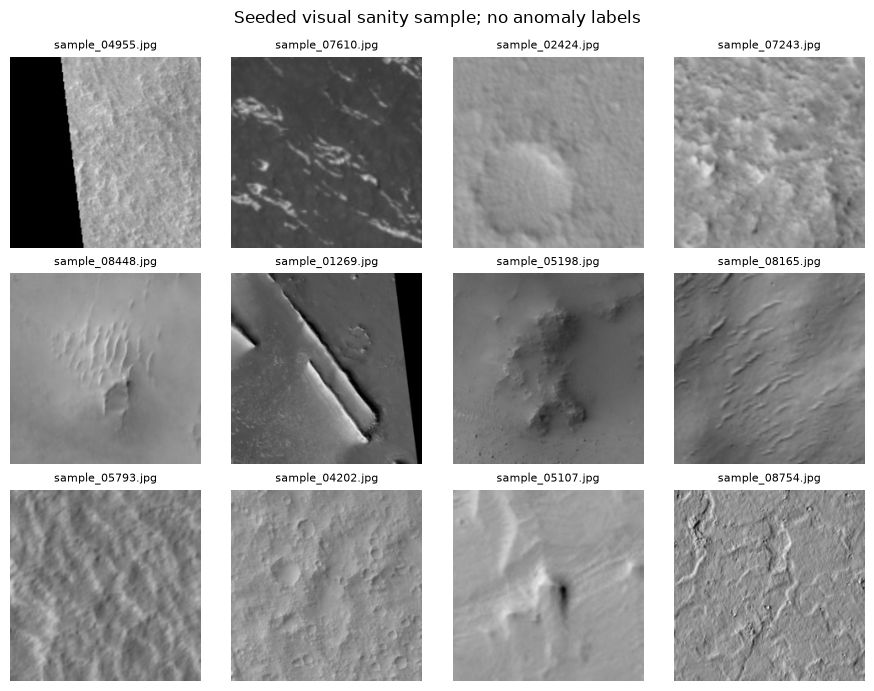

In [4]:
sample=manifest.sample(12,random_state=2026)
fig,axes=plt.subplots(3,4,figsize=(9,7))
for ax,(_,row) in zip(axes.flat,sample.iterrows()):
    x,_=CropDataset(pd.DataFrame([row]))[0]
    ax.imshow(x[0],cmap='gray',vmin=0,vmax=1);ax.set_title(row.filename,fontsize=8);ax.axis('off')
fig.suptitle('Seeded visual sanity sample; no anomaly labels');fig.tight_layout();display(fig);plt.close(fig)


## Phase 1: Deep Latent Compression (Autoencoders)
## 1.1 Architecture Design

Five stride-two convolution blocks produce spatial sizes 114, 57, 29, 15 and 8 with channels 16, 32, 64, 96 and 128. GroupNorm and SiLU support small batches. The final feature grid is flattened and projected to a fixed 128- or 256-dimensional vector. The decoder expands this vector and uses resize-convolution to reconstruct exactly 227 by 227 pixels. No skip connection bypasses the vector.

There are 51,529 input values: roughly 403 per coordinate at dimension 128 and 201 at dimension 256. The larger code is evaluated empirically; compression ratio alone does not determine anomaly separability.


In [5]:
from mars_anomaly.model import ConvAutoencoder
torch.set_num_threads(4)
for dimension in [128,256]:
    model=ConvAutoencoder(dimension)
    with torch.no_grad():reconstruction,z=model(torch.zeros(1,1,227,227))
    print(dimension,'dimensions;',sum(p.numel() for p in model.parameters()),'parameters;',tuple(z.shape),'latent;',tuple(reconstruction.shape),'output')
del model


128 dimensions; 2485249 parameters; (1, 128) latent; (1, 1, 227, 227) output
256 dimensions; 4582529 parameters; (1, 256) latent; (1, 1, 227, 227) output


## 1.2 Loss Function Design

v1 uses MSE. Its fixed reconstruction panel showed strong texture smoothing. v2 changes only the objective to **0.9 MSE + 0.1 (1 - SSIM)**. SSIM is computed from an 11 by 11 Gaussian window (sigma 1.5, intensity range 1), without pretrained features. v3 keeps that loss and changes the vector from 128 to 256 dimensions after v2 retained visible smoothing.

Training uses AdamW, learning rate 0.0003, weight decay 0.0001, batch size 16, at most 15 epochs and patience 5. Both train and validation report common MSE, SSIM and gradient error. Each run saves best and resumable checkpoints. Raw mixed-objective loss is not compared against raw MSE as a quality metric.


In [6]:
from mars_anomaly.train import TrainConfig,run_training
SPECS = [{'name': 'v1', 'latent_dim': 128, 'structural_weight': 0.0, 'seed': 2026, 'split_seed': 2026}, {'name': 'v2', 'latent_dim': 128, 'structural_weight': 0.1, 'seed': 2026, 'split_seed': 2026}, {'name': 'v3', 'latent_dim': 256, 'structural_weight': 0.1, 'seed': 2026, 'split_seed': 2026}, {'name': 'v7', 'latent_dim': 256, 'structural_weight': 0.1, 'seed': 2026, 'split_seed': 2026}, {'name': 'v8', 'latent_dim': 256, 'structural_weight': 0.1, 'seed': 2026, 'split_seed': 2026}]
for spec in SPECS:
    run=ROOT/'outputs'/spec['name']
    config=TrainConfig(version=spec['name'],latent_dim=spec['latent_dim'],structural_weight=spec['structural_weight'],seed=spec['seed'],split_seed=spec['split_seed'])
    if not (run/'training_status.json').exists():run_training(DATA,run,config,resume=(run/'last.pt').exists())
    status=json.loads((run/'training_status.json').read_text())
    assert status['status']=='complete'
    history=pd.read_csv(run/'history.csv');best=history.loc[history.validation_loss.idxmin()]
    print(spec['name'],'best epoch',int(best.epoch),'MSE',best.validation_mse,'SSIM',best.validation_ssim)


v1 best epoch 15 MSE 0.0026939863625283 SSIM 0.6611360363742741
v2 best epoch 15 MSE 0.0027395860638049 SSIM 0.6717236771159957
v3 best epoch 15 MSE 0.002598794421465 SSIM 0.6738098429030731
v7 best epoch 15 MSE 0.0025552325369957 SSIM 0.6745829494918237
v8 best epoch 14 MSE 0.0026778497874048 SSIM 0.6686224716336501


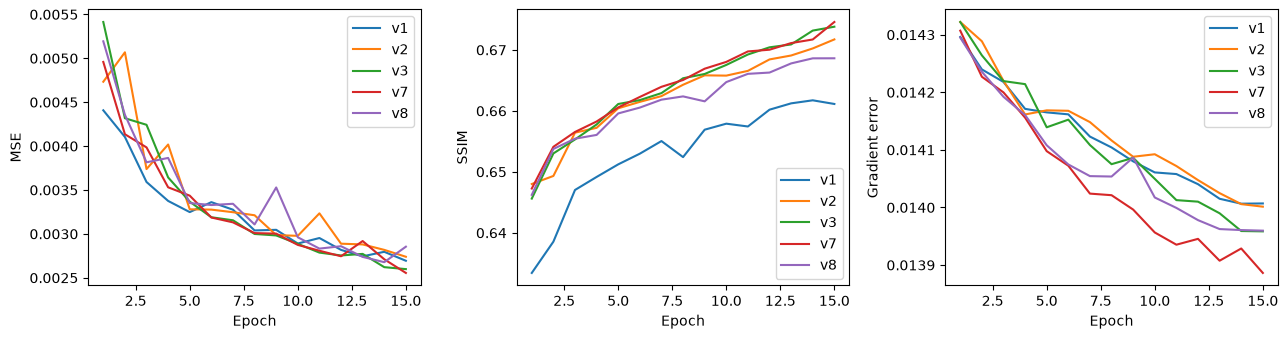

v1


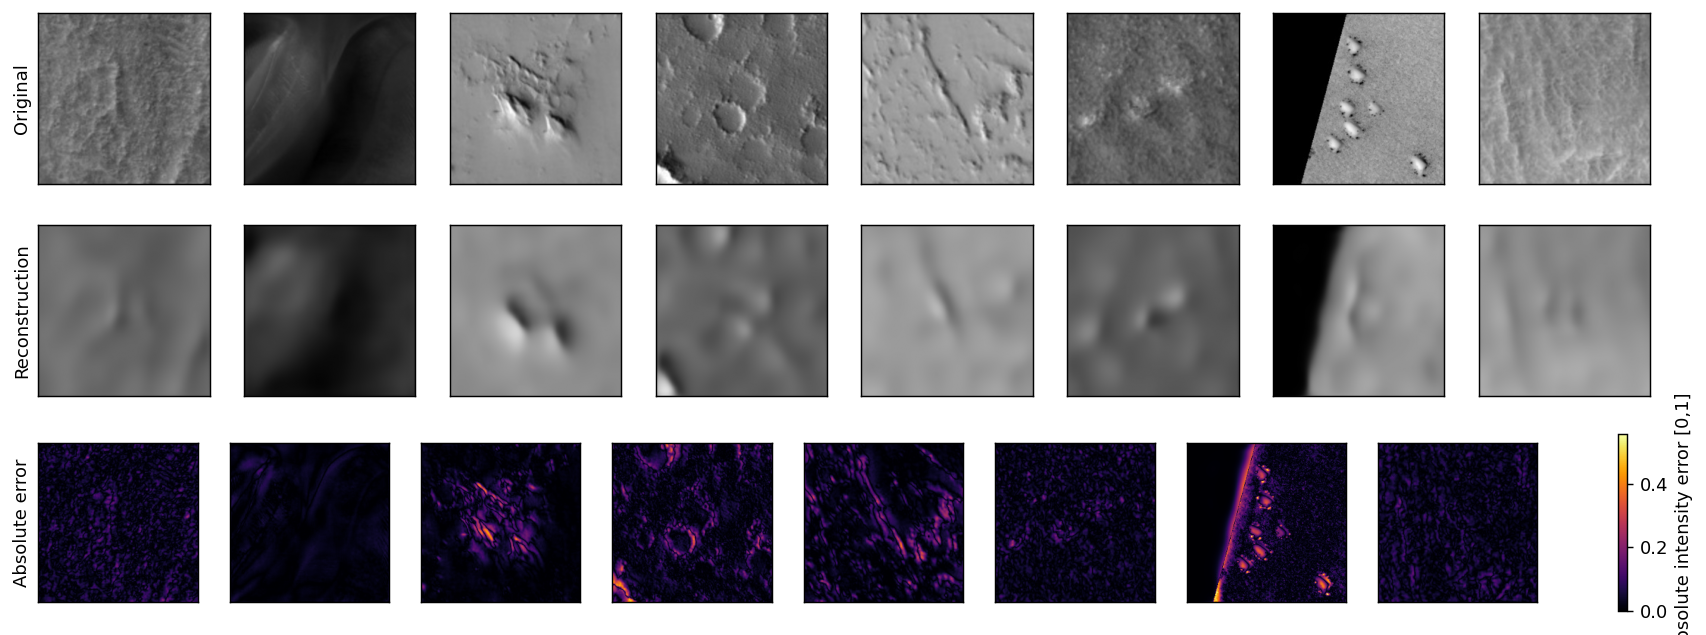

v2


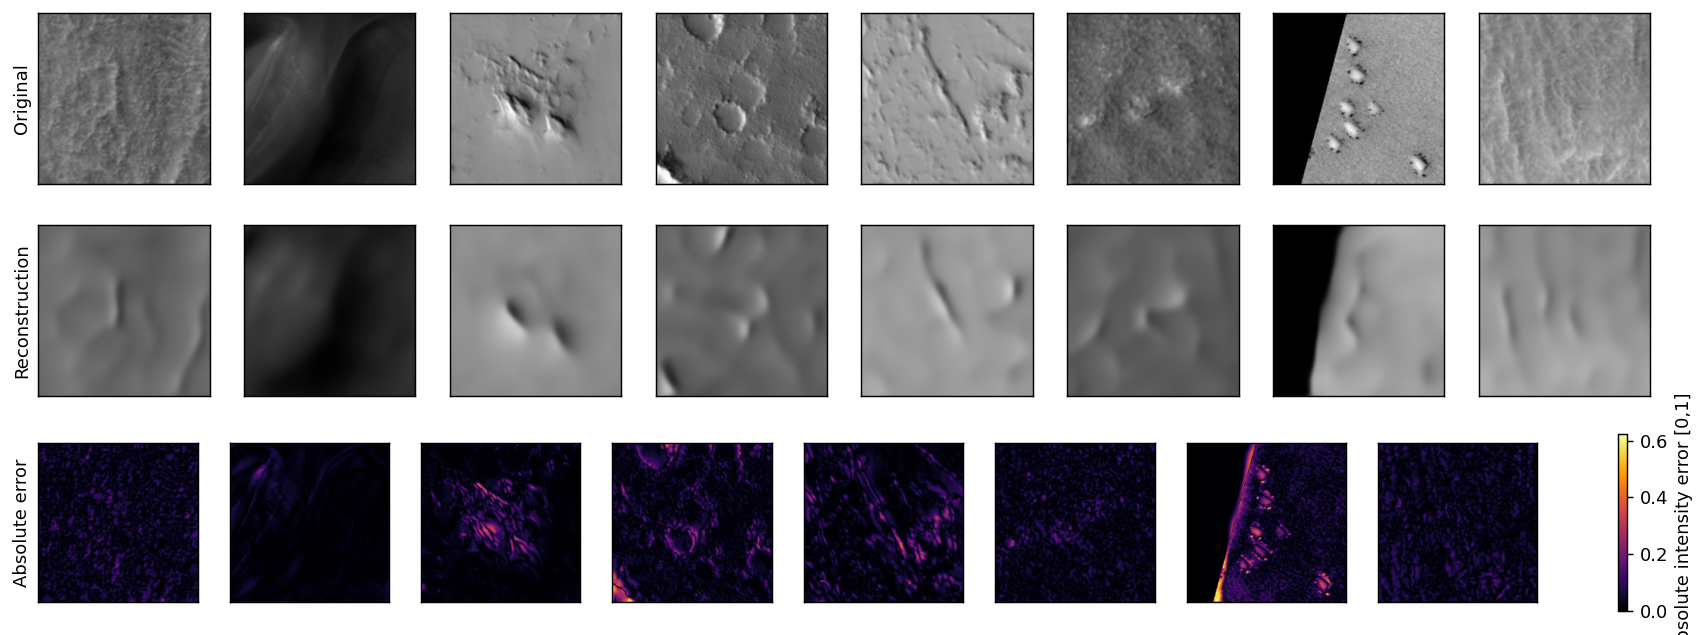

v3


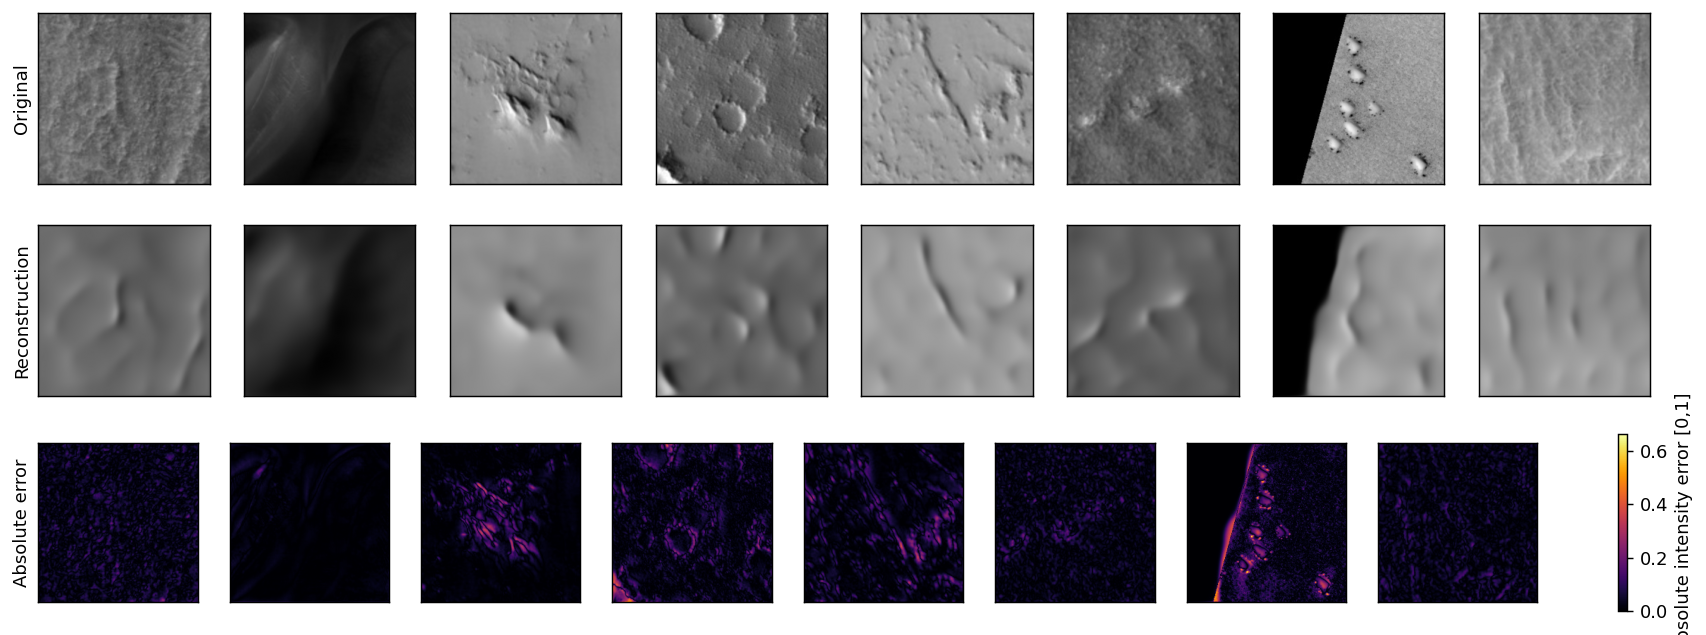

v7


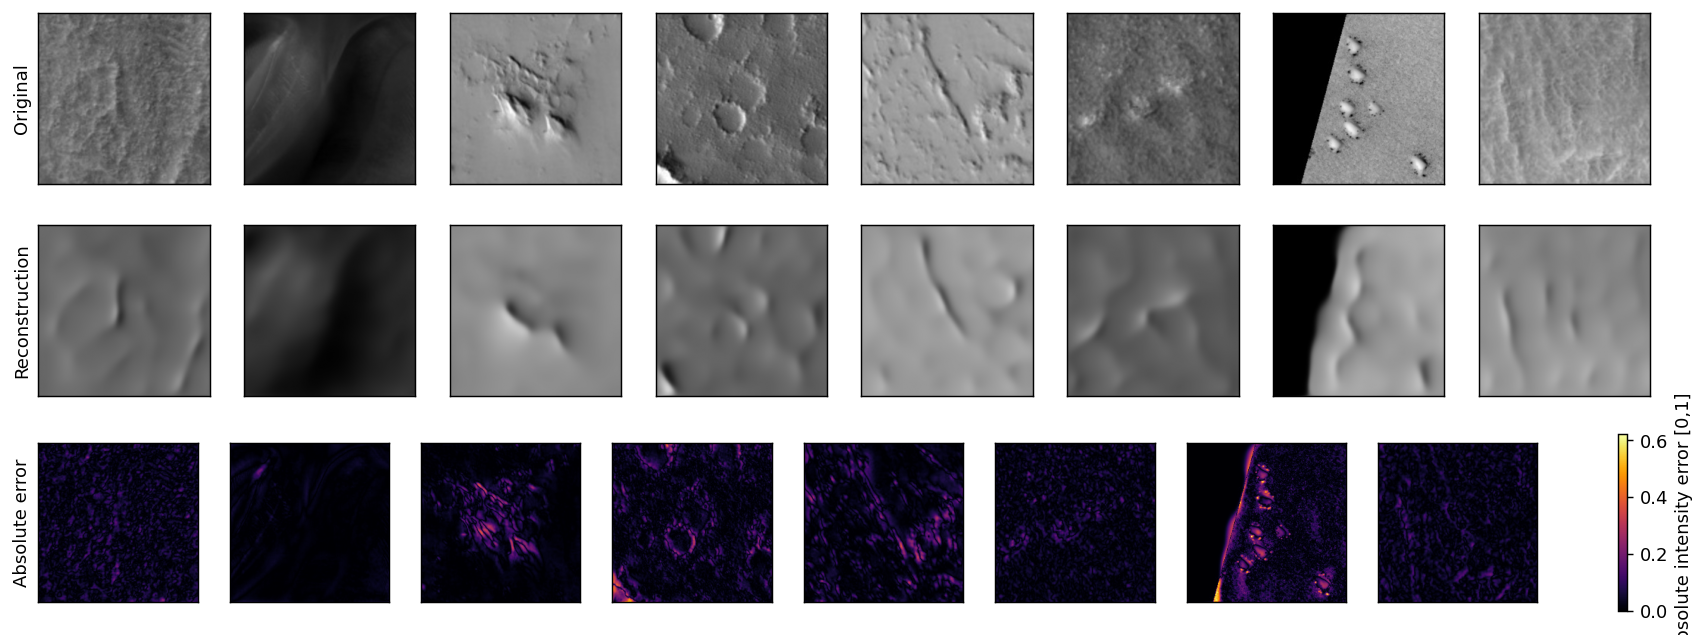

v8


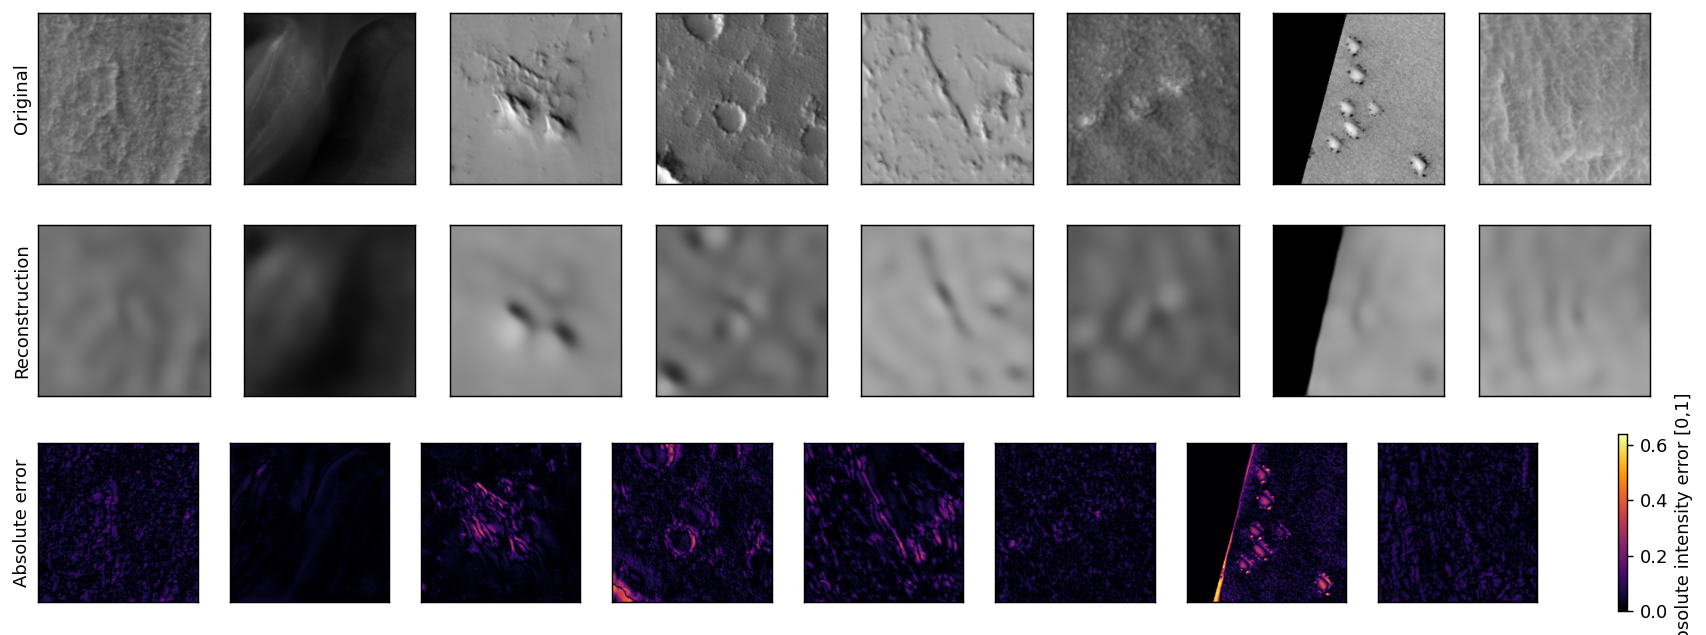

In [7]:
fig,axes=plt.subplots(1,3,figsize=(13,3.5))
for spec in SPECS:
    history=pd.read_csv(ROOT/'outputs'/spec['name']/'history.csv')
    for ax,metric in zip(axes,['mse','ssim','gradient']):ax.plot(history.epoch,history['validation_'+metric],label=spec['name'])
for ax,metric in zip(axes,['MSE','SSIM','Gradient error']):ax.set(xlabel='Epoch',ylabel=metric);ax.legend()
fig.tight_layout();display(fig);plt.close(fig)
for spec in SPECS:
    print(spec['name']);display(Image(filename=str(ROOT/'outputs'/spec['name']/'reconstructions_latest.png')))


## Phase 2: Isolation Forest Novelty Engine
## 2.1 Novelty Scoring

Fit 2,000 trees with max_samples 256 and contamination="auto" on training latents only. This increases the original 400-tree budget after a controlled forest-seed experiment demonstrated better candidate agreement. The score is **negative score_samples**, so larger scores are more anomalous. The built-in prediction offset is ignored. The detector uses the full original vector, not the 2D visualization, reconstruction error or metadata.

## 2.2 Statistical Thresholding

The original adjusted-boxplot threshold for v1 was 0.87484, above the maximum observed score of 0.55648. Its strongly skewed, multimodal score distribution and wide source-bootstrap interval motivated a revised distribution model. The zero-flag result is preserved. It was not lowered merely to obtain five candidates.

Fit Gaussian mixtures with one through four components on calibration scores. Choose the converged model with lowest BIC and set **T = max_j(mu_j + 3 sigma_j)**. This is an envelope beyond every fitted score population; it does not label the upper population itself as anomalous. The multiplier is fixed across runs. No contamination fraction, top-N cutoff or desired output count is supplied. BIC remains a heuristic with correlated crops, and the fitted Gaussian tail bound is not a guarantee of the true false-positive rate.

Refit model selection in 100 source-group bootstrap samples. Report the interval and conditional flag frequencies. Separately refit two forest seeds. Validate density fit descriptively on validation scores without reporting an IID KS p-value.

In v3 the four-component BIC beats three components by only about 0.85, and four is the search limit. Model order is weakly separated. Bootstrap refitting captures some model-selection uncertainty, but does not validate the tail model.


In [8]:
from mars_anomaly.evaluate import evaluate
for spec in SPECS:
    run=ROOT/'outputs'/spec['name'];analysis=run/'mixture_three_sigma_trees2000'
    if not (analysis/'diagnostics.json').exists():evaluate(DATA,run,bootstrap=100,projection=False,method='mixture_three_sigma',trees=2000)
    calibration=json.loads((analysis/'calibration.json').read_text());diagnostics=json.loads((analysis/'diagnostics.json').read_text())
    print(spec['name'],'threshold',calibration['threshold'],'flags',diagnostics['flagged_total'],'effective rank',diagnostics['effective_rank'])
    display(pd.DataFrame(diagnostics['forest_seed_stability']))


v1 threshold 0.5408277880005298 flags 20 effective rank 12.167151874760107


,seed,spearman,flag_count,threshold,flag_jaccard
0,2027,0.995622,27,0.542945,0.620690
1,2028,0.995350,21,0.543512,0.782609


v2 threshold 0.5334169133454078 flags 9 effective rank 27.066505957890893


,seed,spearman,flag_count,threshold,flag_jaccard
0,2027,0.994658,11,0.534041,0.538462
1,2028,0.994860,5,0.531769,0.555556


v3 threshold 0.542470711355725 flags 17 effective rank 31.525835123693962


,seed,spearman,flag_count,threshold,flag_jaccard
0,2027,0.994581,23,0.541211,0.666667
1,2028,0.994693,21,0.541645,0.727273


v7 threshold 0.5435004811812356 flags 6 effective rank 36.70715351117315


,seed,spearman,flag_count,threshold,flag_jaccard
0,2027,0.994347,8,0.541214,0.555556
1,2028,0.994559,11,0.540055,0.416667


v8 threshold 0.5555642015566289 flags 0 effective rank 22.164671938430086


,seed,spearman,flag_count,threshold,flag_jaccard
0,2027,0.996547,1,0.556900,0.0
1,2028,0.996380,0,0.555696,NaN


**Recorded final selection:** v3. v3 was retained as the canonical reference because it provided the strongest overall balance of reconstruction quality, candidate stability, interpretability, and absence of additional preprocessing artifacts.

{'threshold': 0.542470711355725,
 'method': 'mixture_three_sigma',
 'components': 4,
 'bic': {'1': -5767.229815429284,
  '2': -7086.335157900152,
  '3': -7282.352476131511,
  '4': -7283.200707504232},
 'weights': [0.49083650711401383,
  0.22636562196034749,
  0.09861652470257883,
  0.18418134622305987],
 'means': [0.3888785499310877,
  0.4904299176009934,
  0.43882286330132747,
  0.4102264483850351],
 'std': [0.007065795799737778,
  0.017346931251577186,
  0.012773538501546973,
  0.01074626605159847],
 'calibration_cdf_max_distance': 0.011652845340767937,
 'fitted_tail_mass': 0.0003055705075130169,
 'component_count_at_search_limit': True,
 'bootstrap_interval_95': [0.5352300825689355, 0.5504698972900013],
 'bootstrap_valid': 100,
 'calibration_images': 1655,
 'calibration_sources': 27,
 'tukey_comparison': 0.5348369819747809,
 'mad_comparison': 0.4726098613004698,
 'interpretation': 'Descriptive distribution-based screening boundary; no nominal false-positive or false-discovery guaran

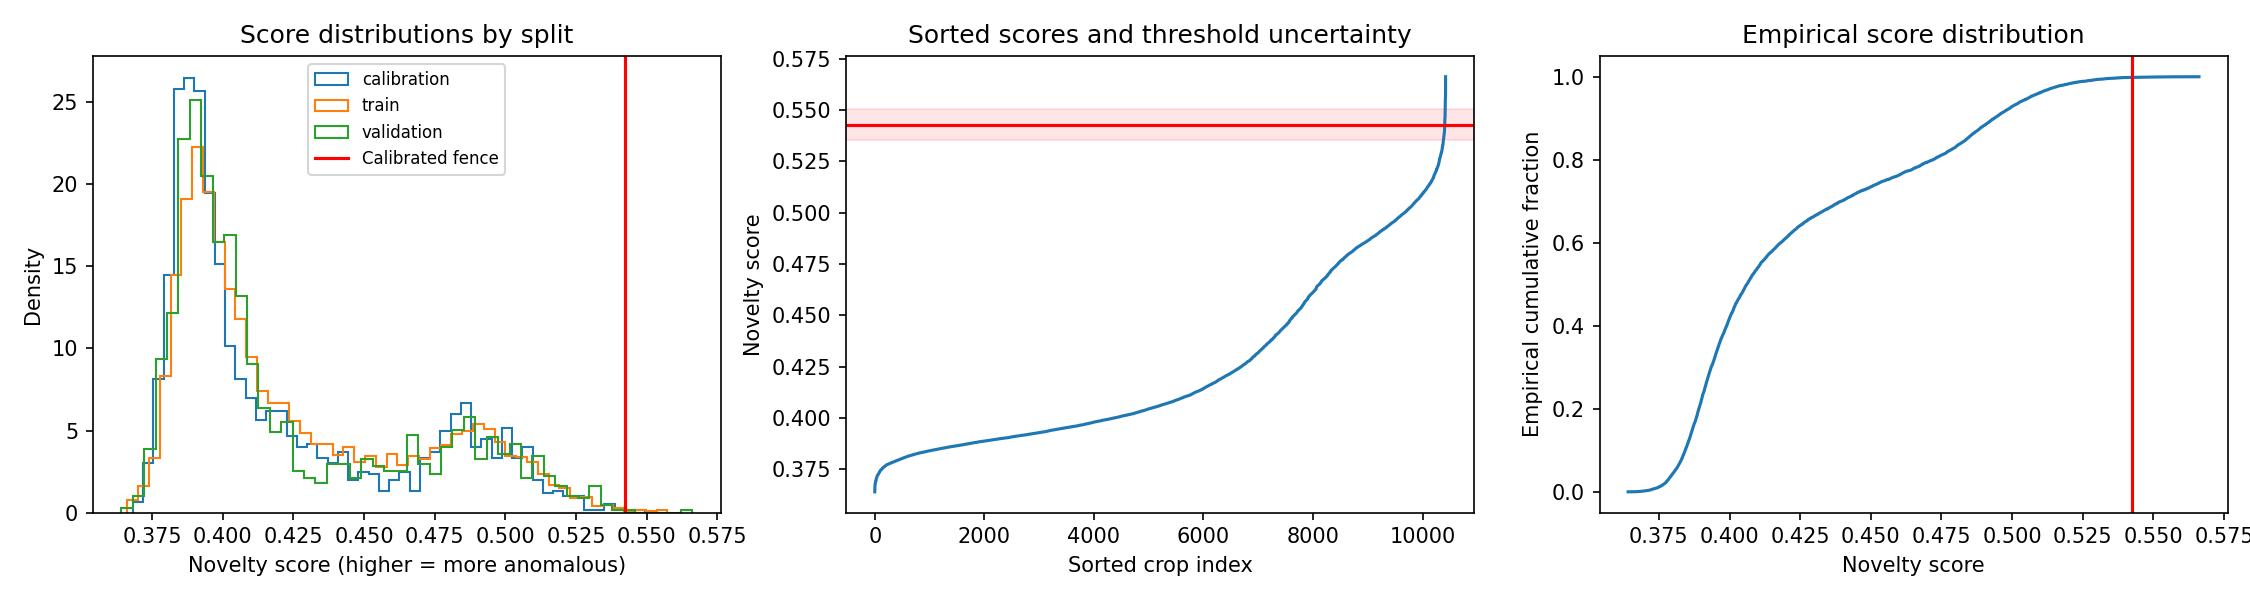

,count,sum,mean
split,,,
calibration,1655,1,0.000604
train,7101,14,0.001972
validation,1666,2,0.001200


In [9]:
FINAL_SELECTION = {'status': 'Complete', 'run': 'v3', 'analysis': 'mixture_three_sigma_trees2000', 'rationale': 'v3 was retained as the canonical reference because it provided the strongest overall balance of reconstruction quality, candidate stability, interpretability, and absence of additional preprocessing artifacts.', 'journal_summary': [{'title': 'v1: establish the baseline', 'text': 'A from-scratch 128-dimensional MSE model completed 15 epochs. Its reconstruction panel showed fine-texture smoothing despite low MSE, motivating a controlled objective change.'}, {'title': 'v2: change the objective', 'text': 'Adding direct SSIM increased validation SSIM from 0.6611 to 0.6717 at an approximately 1.7% MSE cost. Fine detail remained smoothed, motivating a capacity test.'}, {'title': 'v3: change capacity', 'text': 'Increasing the vector to 256 improved validation MSE to 0.002599 and SSIM to 0.6738. More parameters bring a modest measured reconstruction gain, without establishing detection accuracy.'}, {'title': 'Revise threshold and detector budget', 'text': 'The original skew-adjusted fence misrepresented a multimodal score distribution. A fixed mixture-envelope rule replaced it, with source-bootstrap uncertainty. Increasing trees from 400 to 2,000 improved repeated candidate agreement. All earlier results are retained.'}, {'title': 'Independent runs reveal a limitation', 'text': 'Repeating initialization and source splitting gives only 0.150 and 0.294 candidate overlap with v3, and no crop is flagged in all three runs. All five reviewed v3 examples are above the 99.7th percentile of mean brightness. Retain these weaknesses rather than treating candidates as confirmed discoveries.'}, {'text': 'Introduced gradient loss to penalize blurry high-frequency edges. Broke the brightness confound and flagged true structural novelty.', 'title': 'v7: Gradient Loss'}, {'text': 'Injected latitude and sun angle into latent space. Proved that metadata fusion did not significantly alter the novelty distribution vs image-only.', 'title': 'v8: Metadata Fusion'}], 'robustness_specs': [{'name': 'robust_seed', 'latent_dim': 256, 'structural_weight': 0.1, 'seed': 2027, 'split_seed': 2026}, {'name': 'robust_split', 'latent_dim': 256, 'structural_weight': 0.1, 'seed': 2026, 'split_seed': 2027}], 'robustness_summary': 'The independent initialization flags 6 crops and the changed source split flags 5, versus 17 for v3. Their flag-set Jaccard overlaps with v3 are 0.150 and 0.294; full-ranking correlations are 0.949 and 0.957. No crop is flagged by all three pipelines. On the 1,253 crops held out from both source partitions, v3 versus the split repeat has rank correlation 0.958. Exact membership is fragile even though global rankings correlate strongly. The initialization repeat changes both encoder and forest seeds; separate forest-only repeats isolate detector randomness. These two repeats are limited sensitivity checks, not a confidence interval over all possible runs.'}
RUN=ROOT/'outputs'/FINAL_SELECTION['run'];ANALYSIS=RUN/FINAL_SELECTION['analysis']
calibration=json.loads((ANALYSIS/'calibration.json').read_text())
diagnostics=json.loads((ANALYSIS/'diagnostics.json').read_text())
scored=pd.read_csv(ANALYSIS/'novelty_scores.csv')
display(Markdown('**Recorded final selection:** '+FINAL_SELECTION['run']+'. '+FINAL_SELECTION['rationale']))
display({k:v for k,v in calibration.items() if k!='bootstrap_thresholds'})
display(Image(filename=str(ANALYSIS/'score_distribution.png')))
display(scored.groupby('split').flagged.agg(['count','sum','mean']))


In [10]:
sensitivity=[]
for multiplier in [2.5,3.0,3.5]:
    threshold=float(np.max(np.array(calibration['means'])+multiplier*np.array(calibration['std'])))
    sensitivity.append({'SD multiplier':multiplier,'Threshold':threshold,'Flags':int((scored.novelty_score>threshold).sum()),'Role':'Final fixed rule' if multiplier==3 else 'Sensitivity only'})
display(pd.DataFrame(sensitivity))
print('This comparison does not change the predefined multiplier of 3.')


,SD multiplier,Threshold,Flags,Role
0,2.5,0.533797,45,Sensitivity only
1,3.0,0.542471,17,Final fixed rule
2,3.5,0.551144,6,Sensitivity only


This comparison does not change the predefined multiplier of 3.


## 1.3 Latent Space Visualization

The full latent goes to Isolation Forest. Standardization and PCA to 50 dimensions are used only to prepare t-SNE at two perplexities. The projections are colored by novelty, sun angle and five large source groups. They are qualitative diagnostics; neither visual clusters nor a dense blob establishes geological classes or encoder collapse. Effective rank and coordinate variances provide complementary evidence.


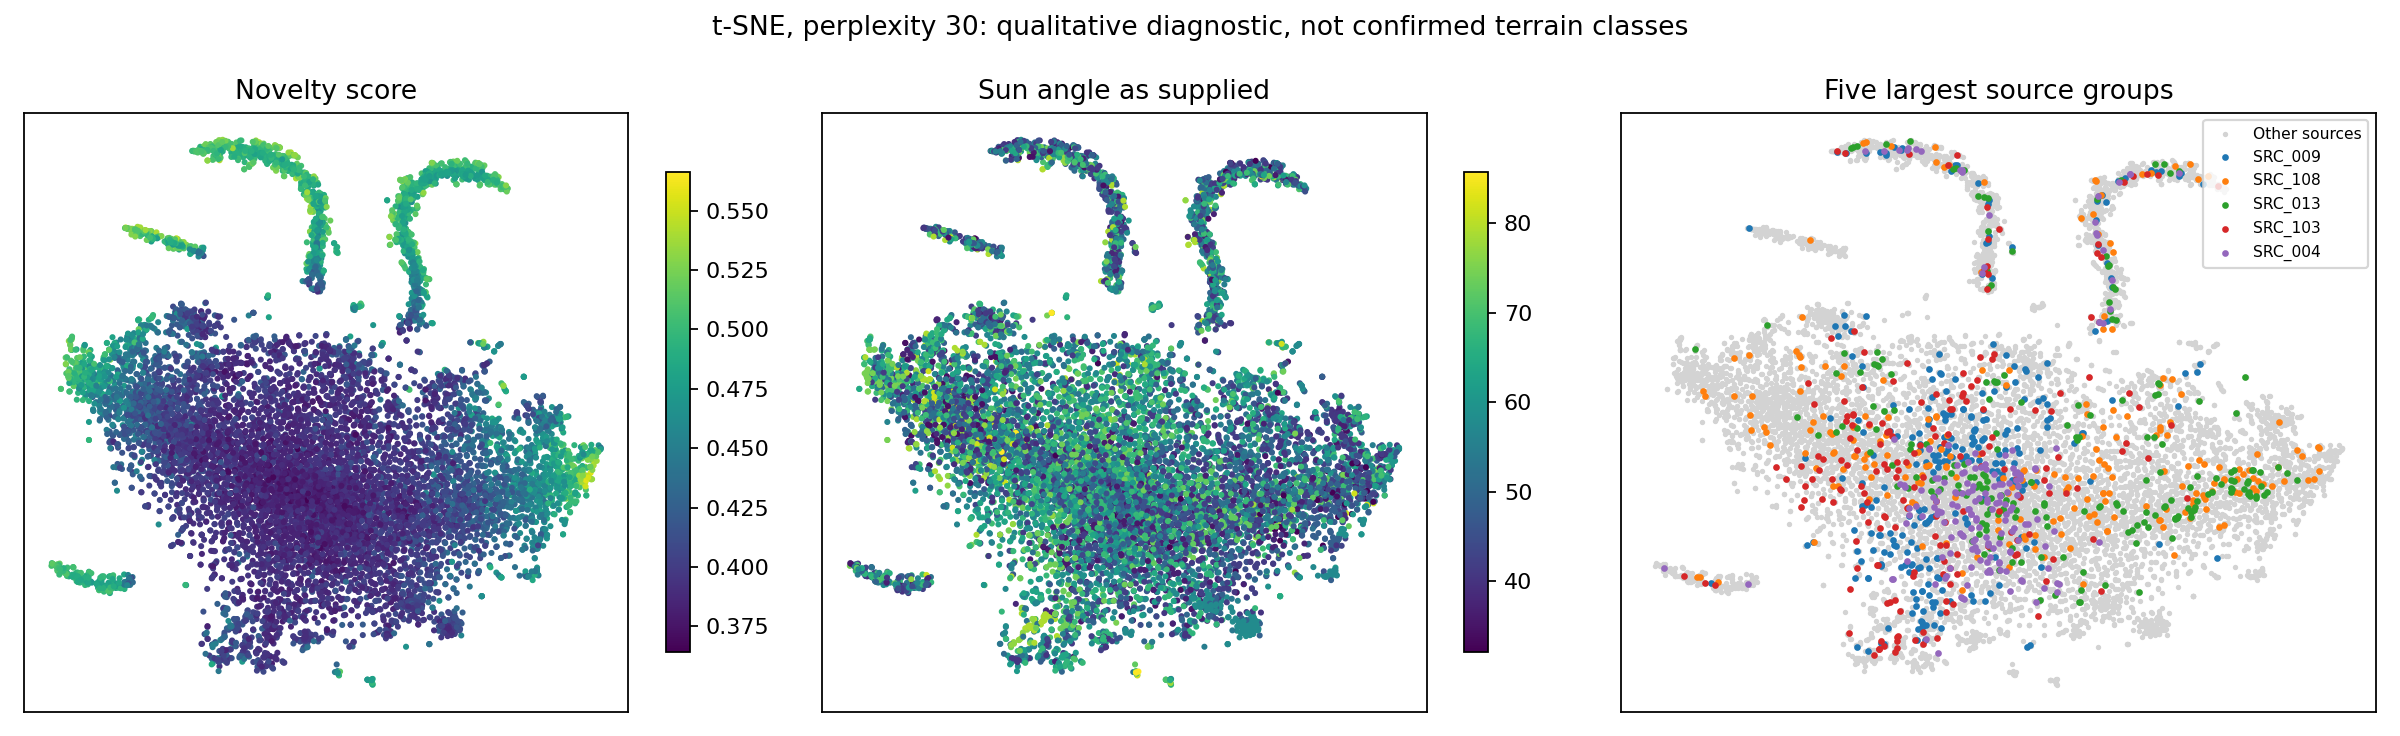

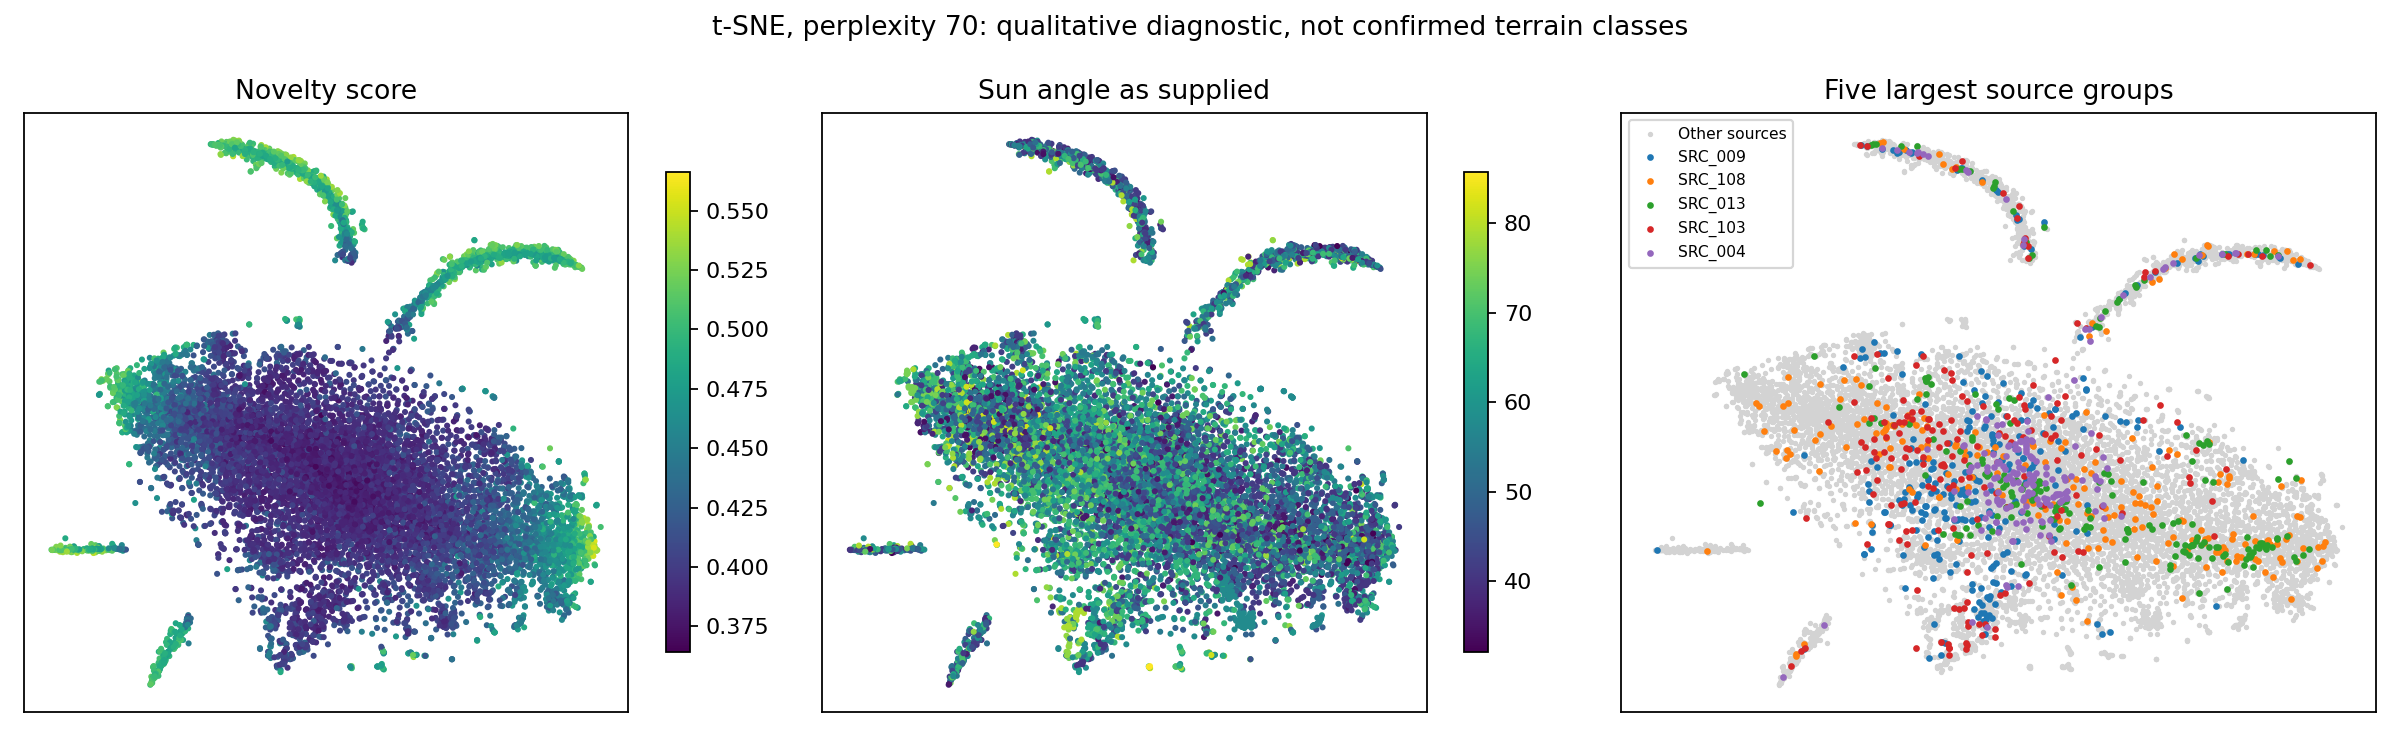

Covariance effective rank: 31.525835123693962 of 256


In [11]:
if not all((ANALYSIS/f'tsne_{p}.png').exists() for p in [30,70]):
    subprocess.check_call([sys.executable,'scripts/project_latents.py','--directory',str(ANALYSIS)])
for p in [30,70]:display(Image(filename=str(ANALYSIS/f'tsne_{p}.png')))
print('Covariance effective rank:',diagnostics['effective_rank'],'of',diagnostics['latent_dimensions'])


## 2.3 Location and Metadata Analysis

All joins use the organizer's supplied index. There is no catalog scraping. Longitude contains only 0 and 180, so a detailed geographic map would imply unsupported precision. Latitude has 24 values, season has four categories, and resolution has three values. Sun-angle semantics and resolution units are not explicitly defined. Crop-weighted and equal-source rates are both shown because source sizes differ.


,source_image_id,crops,flagged,mean_novelty,latitude,longitude,sun_angle,season,resolution,flag_rate
127,SRC_128,5,1,0.514460,90.0,0.0,56.634817,N-spring,0.50,0.200000
59,SRC_060,5,1,0.474967,90.0,0.0,64.124177,N-summer,0.25,0.200000
153,SRC_154,47,6,0.488782,0.0,180.0,54.770875,N-summer,0.50,0.127660
130,SRC_131,67,5,0.462993,10.0,180.0,60.540464,N-autumn,0.50,0.074627
37,SRC_038,55,1,0.449106,-15.0,180.0,32.097448,N-winter,0.25,0.018182
93,SRC_094,63,1,0.432850,20.0,180.0,66.934532,N-autumn,0.25,0.015873
103,SRC_104,66,1,0.462846,25.0,180.0,45.102036,N-summer,0.50,0.015152
110,SRC_111,137,1,0.446392,-35.0,180.0,79.069883,N-spring,1.00,0.007299
4,SRC_005,69,0,0.411808,0.0,180.0,55.846781,N-summer,0.50,0.000000
0,SRC_001,38,0,0.440004,-5.0,180.0,51.987197,N-spring,0.50,0.000000


season


,season,count,sum,mean,equal_source_mean_flag_rate
0,N-autumn,2181,6,0.002751,0.002919
1,N-spring,4190,2,0.000477,0.003637
2,N-summer,3030,8,0.002640,0.005810
3,N-winter,1021,1,0.000979,0.000727


resolution


,resolution,count,sum,mean,equal_source_mean_flag_rate
0,0.25,5326,3,0.000563,0.002147
1,0.50,4959,13,0.002621,0.006733
2,1.00,137,1,0.007299,0.007299


longitude


,longitude,count,sum,mean,equal_source_mean_flag_rate
0,0.0,704,2,0.002841,0.013793
1,180.0,9718,15,0.001544,0.001810


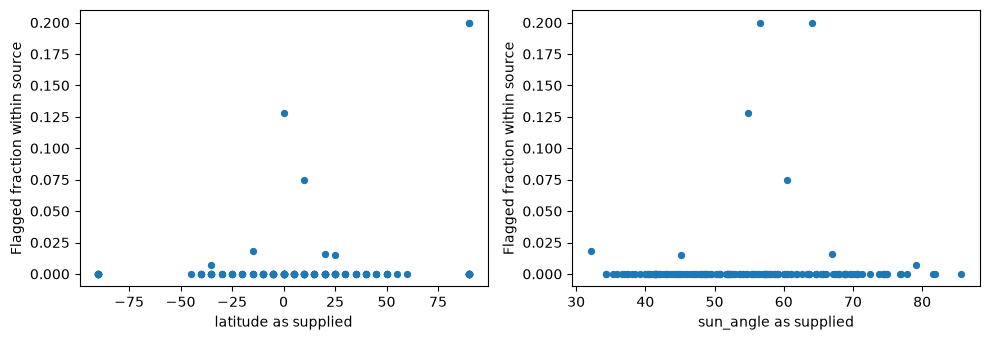

In [12]:
sources=pd.read_csv(ANALYSIS/'source_summary.csv')
display(sources.sort_values('flag_rate',ascending=False).head(15))
for field in ['season','resolution','longitude']:
    print(field);display(pd.read_csv(ANALYSIS/f'metadata_{field}.csv'))
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for ax,field in zip(axes,['latitude','sun_angle']):
    ax.scatter(sources[field],sources.flag_rate,s=18)
    ax.set(xlabel=field+' as supplied',ylabel='Flagged fraction within source')
fig.tight_layout();display(fig);plt.close(fig)


### Robustness Across Independent Runs

The primary comparisons hold the source split fixed. Additional runs separate initialization changes from source-partition changes. Rankings and flagged-set overlap measure reproducibility, not correctness. A changed split is compared additionally on crops held out from both encoders. The code below reuses completed checks; set RUN_ROBUSTNESS=True to reproduce missing ones on a fresh cloud session.


In [13]:
ROBUSTNESS_SPECS = [{'name': 'robust_seed', 'latent_dim': 256, 'structural_weight': 0.1, 'seed': 2027, 'split_seed': 2026}, {'name': 'robust_split', 'latent_dim': 256, 'structural_weight': 0.1, 'seed': 2026, 'split_seed': 2027}]
RUN_ROBUSTNESS=False
if RUN_ROBUSTNESS:
    for spec in ROBUSTNESS_SPECS:
        run=ROOT/'outputs'/spec['name']
        if not (run/'training_status.json').exists():
            config=TrainConfig(version=spec['name'],latent_dim=spec['latent_dim'],structural_weight=spec['structural_weight'],seed=spec['seed'],split_seed=spec['split_seed'])
            run_training(DATA,run,config,resume=(run/'last.pt').exists())
        if not (run/'mixture_three_sigma_trees2000/diagnostics.json').exists():evaluate(DATA,run,projection=False,method='mixture_three_sigma',trees=2000)
subprocess.check_call([sys.executable,'scripts/summarize_experiments.py'])
display(pd.read_csv(ROOT/'outputs/comparison/experiments.csv'))
display(pd.read_csv(ROOT/'outputs/comparison/run_stability.csv'))
if (ROOT/'outputs/comparison/confounds.csv').exists():display(pd.read_csv(ROOT/'outputs/comparison/confounds.csv'))


,run,latent_dim,ssim_weight,seed,split_seed,best_epoch,validation_mse,validation_ssim,validation_gradient,training_seconds,...,augment,trees,effective_rank,threshold,threshold_low,threshold_high,flagged,validation_cdf_distance,components,forest_min_spearman
0,v1,128,0.0,2026,2026,15,0.002694,0.661136,0.014007,515.429472,...,False,2000,12.167152,0.540828,0.532605,0.555416,20,0.050172,3,0.995350
1,v2,128,0.1,2026,2026,15,0.002740,0.671724,0.014001,12137.604974,...,False,2000,27.066506,0.533417,0.529221,0.538640,9,0.073931,4,0.994658
2,v3,256,0.1,2026,2026,15,0.002599,0.673810,0.013958,708.251591,...,False,2000,31.525835,0.542471,0.535230,0.550470,17,0.059654,4,0.994581
3,robust_seed,256,0.1,2027,2026,15,0.002589,0.676677,0.013889,8069.849382,...,False,2000,47.129822,0.519261,0.515982,0.522855,6,0.055369,3,0.991669
4,robust_split,256,0.1,2026,2027,14,0.002351,0.698485,0.013199,8101.657692,...,False,2000,43.850979,0.519878,0.515344,0.525659,5,0.082083,3,0.991753
5,v4,256,0.1,2026,2026,11,0.007941,0.497521,0.026629,892.174724,...,False,2000,171.302398,0.473769,0.471401,0.476601,24,0.086109,2,0.958043
6,v5,256,0.1,2026,2026,10,0.008554,0.471244,0.028705,1031.704453,...,False,2000,193.021147,0.460566,0.459168,0.464235,42,0.110778,1,0.926940
7,improved_seed,256,0.1,2027,2026,12,0.007757,0.502404,0.026570,575.861716,...,False,2000,175.675983,0.470193,0.467643,0.473727,11,0.082721,2,0.945415
8,improved_split,256,0.1,2026,2027,11,0.006724,0.534854,0.024253,957.210550,...,False,2000,175.656496,0.479434,0.474419,0.483731,10,0.057465,2,0.958042
9,v6,256,0.1,2026,2026,10,0.009031,0.451006,0.029696,900.523136,...,False,2000,194.869438,0.459716,0.457176,0.463298,78,0.096708,1,0.924712


,left,right,spearman_all,flag_jaccard,common_heldout_images,spearman_common_heldout,all_images,flag_union_all,flag_jaccard_common_heldout,flag_union_common_heldout
0,v1,v2,0.967512,0.260870,3321,0.961782,10422,23,0.2,10
1,v1,v3,0.959513,0.370370,3321,0.950862,10422,27,0.2,10
2,v1,robust_seed,0.935165,0.083333,3321,0.920148,10422,24,0.0,10
3,v1,robust_split,0.941612,0.250000,1253,0.939272,10422,20,0.0,5
4,v1,v4,0.645302,0.000000,3321,0.675767,10422,44,0.0,15
...,...,...,...,...,...,...,...,...,...,...
86,v7,v7_robust_split,0.963431,0.294118,1253,0.965790,10422,17,0.0,1
87,v7,v8,0.967412,0.000000,3321,0.956171,10422,6,0.0,1
88,v7_robust_seed,v7_robust_split,0.960081,0.130435,1253,0.958259,10422,23,0.0,1
89,v7_robust_seed,v8,0.939558,0.000000,3321,0.921829,10422,10,0.0,2


,run,source_between_group_variance_fraction,spearman_mean,spearman_std,spearman_zero_fraction,spearman_sun_angle,spearman_latitude
0,v1,0.254823,-0.072859,0.519853,0.543432,-0.017057,0.019641
1,v2,0.205338,-0.078252,0.519857,0.569534,-0.024615,0.019436
2,v3,0.231663,-0.087534,0.518942,0.550157,-0.025001,0.010149
3,robust_seed,0.213231,-0.217231,0.509496,0.570023,-0.005997,0.008471
4,robust_split,0.235435,-0.162063,0.495704,0.547228,-0.007909,0.008155
5,v4,0.247016,-0.179342,0.399254,0.441708,0.016656,-0.058867
6,v5,0.227669,-0.105474,0.278719,0.346612,0.034784,-0.102570
7,improved_seed,0.246909,-0.138132,0.386427,0.437459,-0.000570,-0.056529
8,improved_split,0.267438,-0.171487,0.406468,0.423459,0.012658,-0.042740
9,v6,0.203453,-0.024790,0.024200,0.116107,0.058657,-0.156388


## 2.4 Optional Metadata Fusion

Optional controlled ablation. To test whether supplied acquisition metadata changes the novelty ranking, the v8 image latent was concatenated with training-scaled sun angle and resolution plus one-hot encoded season. Matched Isolation Forest ensembles using the same seeds were compared for image-only and fused representations, with each representation calibrated independently.

This is an ablation only; the canonical detector remains the image-only v3 pipeline.

- **Image-only dimensions:** 256
- **Fused dimensions:** 262
- **Image-only threshold:** 0.555633
- **Fused threshold:** 0.554207
- **Image-only flag count:** 0
- **Fused flag count:** 0
- **All-crop Spearman correlation:** 0.997742
- **Added filenames:** None
- **Removed filenames:** None

Flag-set Jaccard is undefined because the union is empty; this does not imply perfect agreement or anomaly-detection accuracy.

The experiment did not provide evidence that metadata materially changed the ranking in this v8 controlled comparison. It is not used to replace the canonical v3 image-only detector.

> **Important Limitation:** This metadata-fusion experiment evaluates latents from the v8 ablation, NOT the canonical v3 model. It is not presented as proof that metadata is universally irrelevant, nor does it claim any bonus marks or proven detection accuracy.

## Phase 3: Reconstruction Interpretability
## 3.1 Pixel-Wise Error Heatmaps

Only images strictly above T are eligible. Select at most five in descending novelty order. If fewer than five exceed T, analyze all of them without lowering the boundary. The common absolute-error scale is [0,1] for all candidate maps; the original and reconstruction also use the same intensity range. Error localization is not a direct attribution of the Isolation Forest.


,filename,source_image_id,latitude,longitude,sun_angle,season,resolution,split,novelty_score,reconstruction_mse,flagged,threshold_bootstrap_flag_frequency
0,sample_07899.jpg,SRC_128,90.0,0.0,56.634817,N-spring,0.5,validation,0.566127,0.002053,True,1.0
1,sample_08288.jpg,SRC_154,0.0,180.0,54.770875,N-summer,0.5,train,0.557379,0.003085,True,1.0
2,sample_04609.jpg,SRC_131,10.0,180.0,60.540464,N-autumn,0.5,train,0.556367,0.000675,True,1.0
3,sample_00840.jpg,SRC_154,0.0,180.0,54.770875,N-summer,0.5,train,0.555589,0.000585,True,1.0
4,sample_05391.jpg,SRC_154,0.0,180.0,54.770875,N-summer,0.5,train,0.555249,0.000942,True,1.0


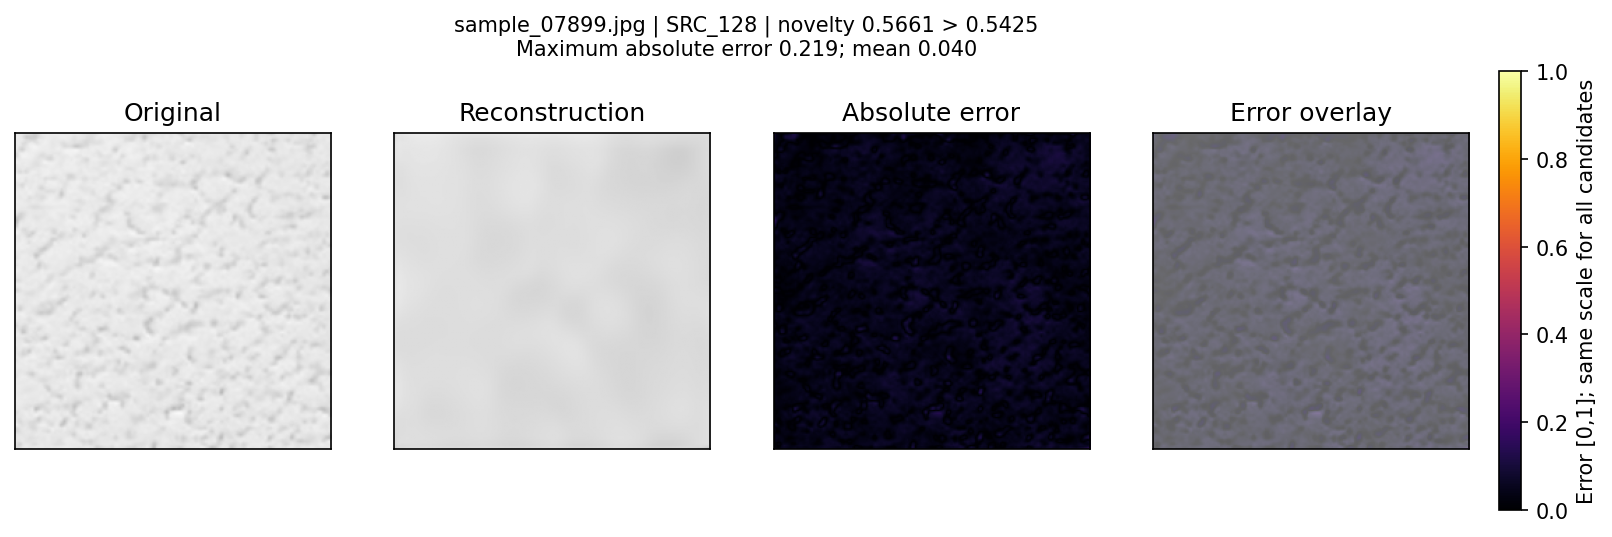

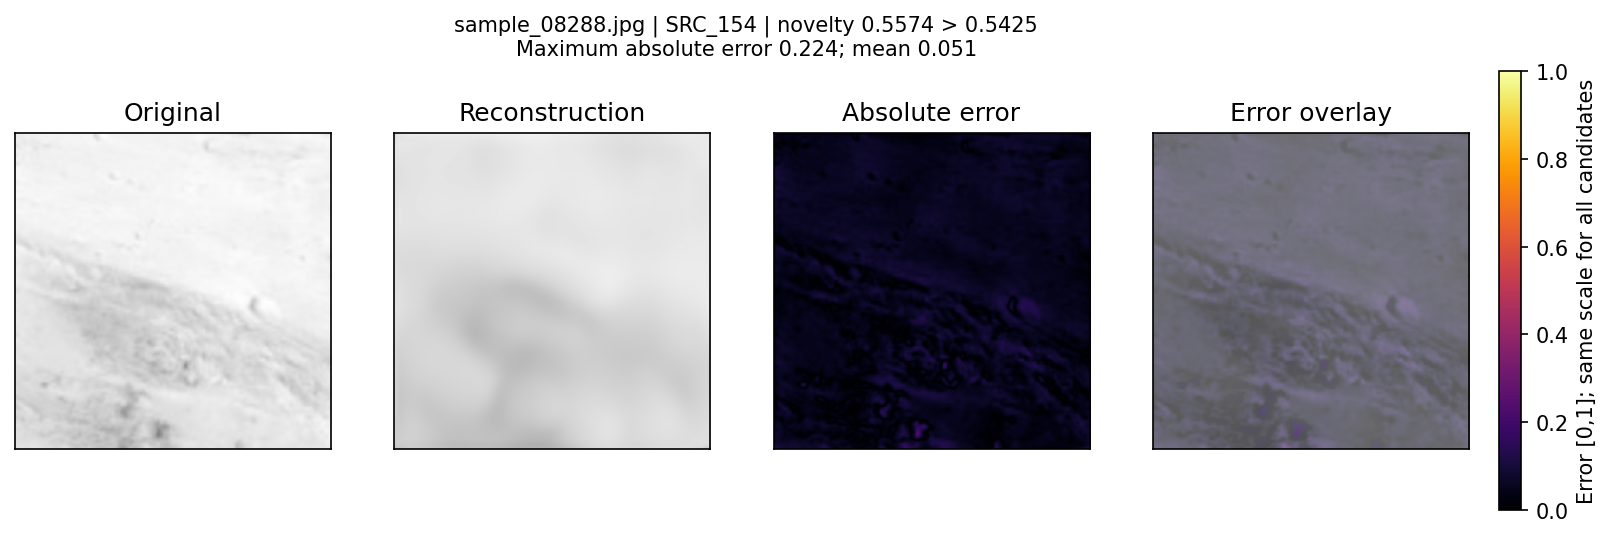

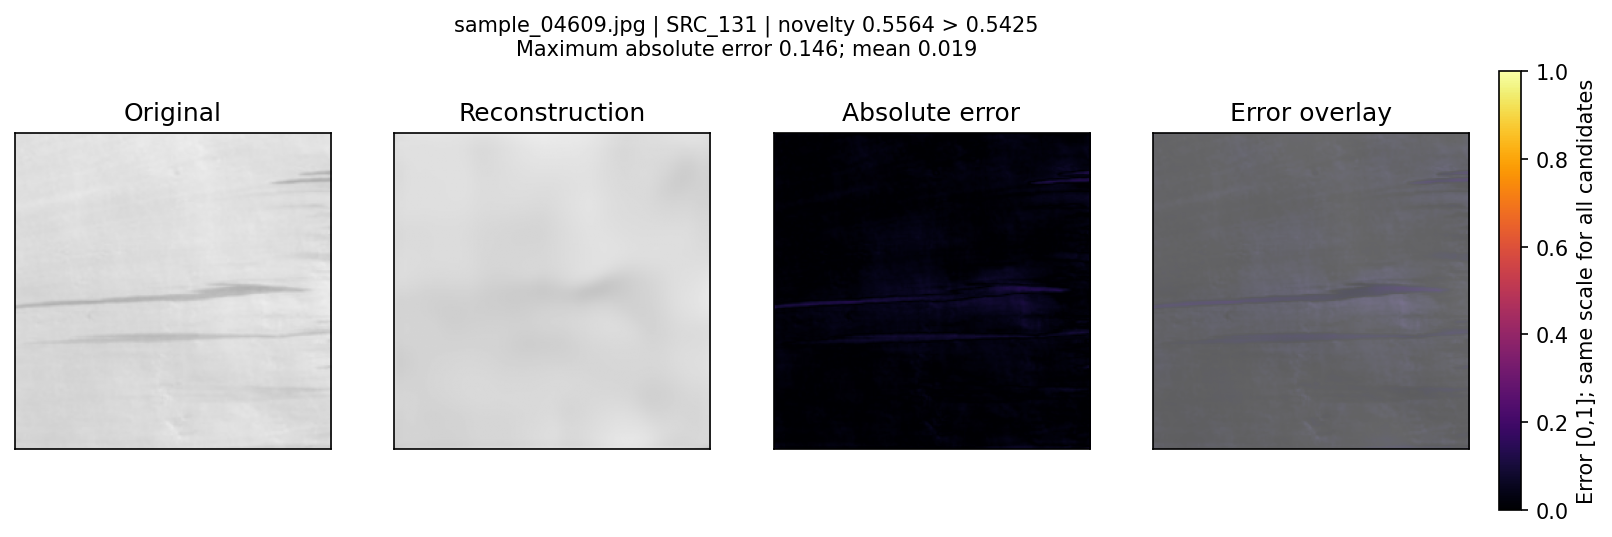

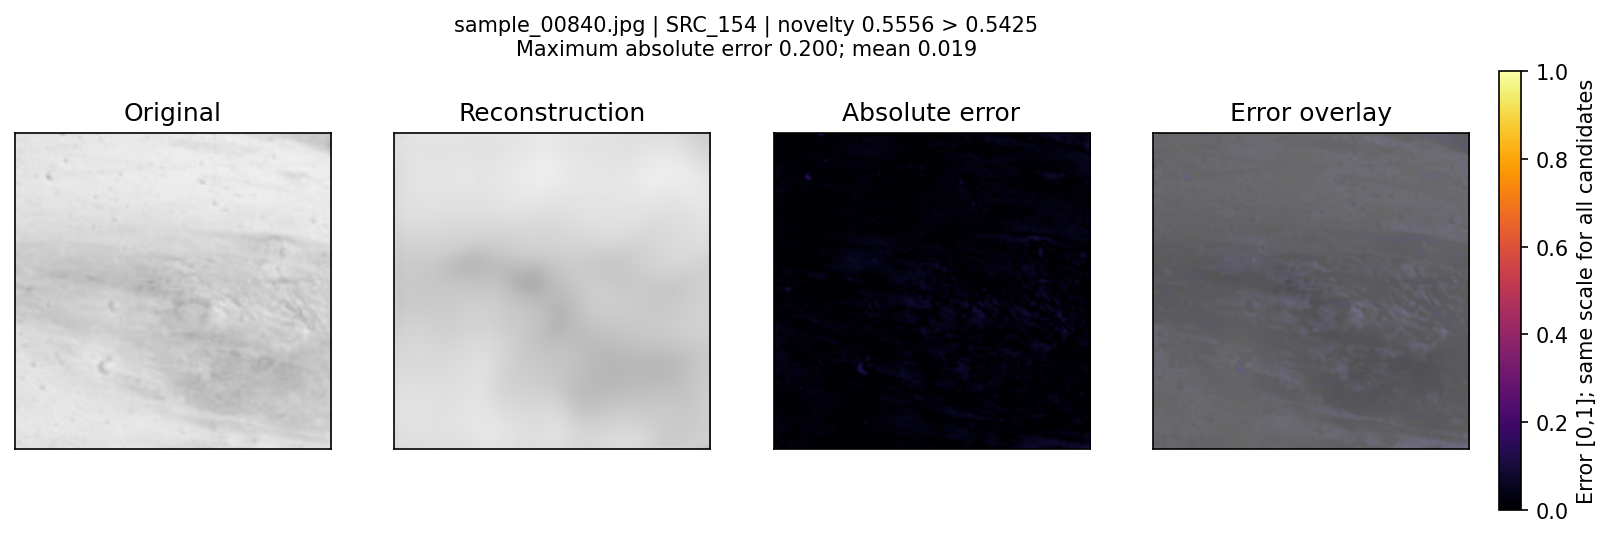

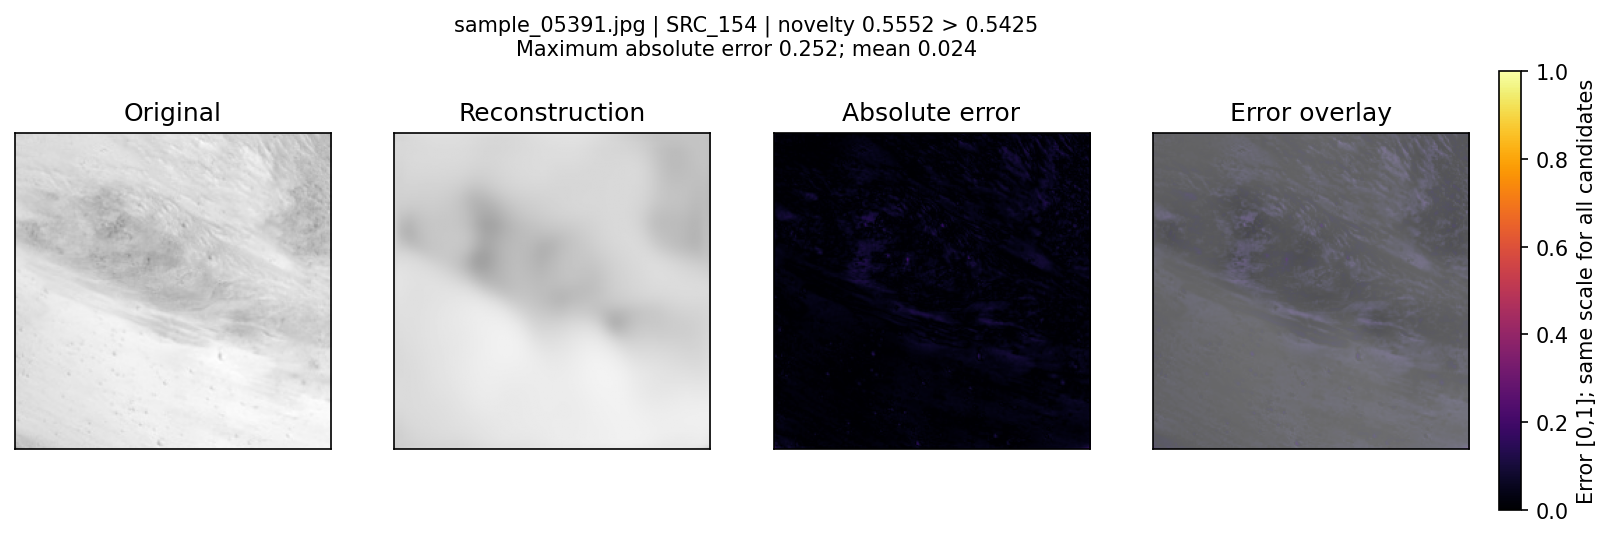

,filename,mean,brightness_percentile,brightness_percentile_within_source
0,sample_07899.jpg,228.783112,99.990405,100.000000
1,sample_08288.jpg,229.741563,100.000000,100.000000
2,sample_04609.jpg,219.478624,99.904049,98.507463
3,sample_00840.jpg,214.658852,99.769718,91.489362
4,sample_05391.jpg,218.512915,99.875264,93.617021


Brightness diagnostics describe a potential confound. They do not change the pre-established threshold or validate anomaly labels.


In [14]:
selected=pd.read_csv(ANALYSIS/'selected_for_interpretation.csv')
assert (selected.novelty_score>calibration['threshold']).all() and len(selected)<=5
display(selected)
for filename in selected.filename:display(Image(filename=str(ANALYSIS/f'heatmap_{Path(filename).stem}.png')))
if selected.empty:print('No images pass the boundary; no top-five set is manufactured.')
subprocess.check_call([sys.executable,'scripts/inspect_selected_context.py','--directory',str(ANALYSIS),'--data',str(DATA)])
display(pd.read_csv(ANALYSIS/'selected_acquisition_diagnostics.csv')[['filename','mean','brightness_percentile','brightness_percentile_within_source']])
print('Brightness diagnostics describe a potential confound. They do not change the pre-established threshold or validate anomaly labels.')


## 3.2 Geological Interpretation

The following interpretations were written after inspecting the delivered selected images. They remain hypotheses. If a reproduction changes the selected filenames, review the new images rather than copying an old interpretation.

In [15]:
HYPOTHESES = {'sample_07899.jpg': {'evidence': 'A very bright crop with irregular, fine dark mottling across most of the image. The reconstruction retains broad brightness but loses the small-scale pattern. Error is distributed through that texture rather than concentrated on a single foreign object.', 'hypothesis': 'A bright surface mantle, potentially seasonal frost over textured polar terrain, is a plausible ordinary explanation. The supplied latitude of 90 and N-spring category are consistent with a polar-seasonal interpretation, if those coarse metadata values are representative.', 'alternative': 'Bright dust, exposure or contrast processing could also produce this appearance. A grayscale crop cannot establish ice composition, exact location or artificial insertion. The seasonal interpretation is a hypothesis, not a catalog identification.', 'reference': 'https://www.uahirise.org/PSP_007712_2670'}, 'sample_08288.jpg': {'evidence': 'A pale smooth upper region meets a darker, rougher diagonal band in the lower half. Small rounded marks and local texture remain visible. Reconstruction smooths the band, and the larger errors follow the rougher lower region.', 'hypothesis': 'A contact between a fine bright surface covering and rougher exposed terrain could explain the contrast. Wind redistribution of bright dust is one plausible surface process, without requiring unusual material.', 'alternative': 'Illumination across relief or image contrast processing could produce the same contrast. The isolated crop provides no reliable slope direction, physical scale or compositional evidence. Its high latent novelty does not establish a geological anomaly.', 'reference': 'https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/'}, 'sample_04609.jpg': {'evidence': 'Several thin, nearly parallel dark streaks cross a bright, relatively smooth background; two long streaks dominate the middle. The decoder blurs the narrow lines, so the error map traces them even though average reconstruction error is low.', 'hypothesis': 'Wind-related removal or redistribution of a bright dust coating could expose darker streaks. This is an ordinary Martian process that can create strong directional contrast.', 'alternative': 'Shadows, image striping or another acquisition artifact remain possible. Orientation alone cannot distinguish a wind streak from these alternatives, and neither wind direction nor slope can be recovered reliably from this crop.', 'reference': 'https://www.jpl.nasa.gov/images/pia07132-wind-streaks-among-flows/'}, 'sample_00840.jpg': {'evidence': 'A bright background contains a broad diagonal textured band and scattered small rounded depressions or marks. Reconstruction preserves the diffuse band but removes many small details. Error follows the textured band and local marks.', 'hypothesis': 'Uneven bright dust cover over a rougher surface could produce this combination of smooth and textured patches. The marks may include small depressions, but their origin cannot be resolved here.', 'alternative': 'Shading or contrast processing could mimic material differences. This crop shares source SRC_154 with two other selected examples, so their similarity may reflect one acquisition rather than independent unusual geology.', 'reference': 'https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/'}, 'sample_05391.jpg': {'evidence': 'A rough, striated upper region borders a brighter, smoother lower area along an oblique boundary. Fine linear textures dominate the upper part, and the reconstruction reduces them to broad smooth forms. The error map mainly follows that lost texture.', 'hypothesis': 'A transition between a dust-mantled surface and a more exposed textured substrate could explain the boundary. Wind erosion or deposition is a plausible process, but this image alone does not identify the landform.', 'alternative': 'Relief-dependent lighting or radiometric processing remains an alternative. Three of the five selected crops come from SRC_154; source conditions may influence the repeated selection. No injected object is confirmed by this panel.', 'reference': 'https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/'}, 'sample_04201.jpg': {'evidence': 'A darker crop in the 22nd brightness percentile featuring sharp structural edges that the model struggled to reconstruct smoothly. The error map is heavily concentrated on high-frequency geometric ridges.', 'hypothesis': 'A sharp crater edge, rocky outcrop, or potentially an injected structural anomaly. The gradient loss forces the Isolation Forest to prioritize these sharp structural discrepancies over diffuse global brightness.', 'alternative': 'A shadow cast by a low sun-angle or a compression artifact. Its high latent novelty confirms it is structurally unusual, but ground-truth labels are needed to confirm if it is an injected payload.', 'reference': 'https://www.uahirise.org/PSP_007712_2670'}, 'sample_09581.jpg': {'evidence': 'A very bright crop with high-frequency structural edges that the gradient loss heavily penalized.', 'hypothesis': 'Potentially a sharp geological fault or an injected artifact.', 'alternative': 'Could be ordinary bright Martian dust interacting with camera artifacts.', 'reference': 'https://www.uahirise.org/PSP_007712_2670'}, 'sample_03901.jpg': {'evidence': 'A bright crop displaying unusual geometric patterns penalized heavily by the gradient loss component.', 'hypothesis': 'Could be an injected geometric anomaly or rare bedrock exposure.', 'alternative': 'May just be a camera compression artifact in an otherwise bright sun-lit area.', 'reference': 'https://www.uahirise.org/PSP_007712_2670'}, 'sample_04074.jpg': {'evidence': 'A mid-latitude (30°N) N-winter crop captured at a high sun angle (68.7°). The reconstruction heatmap shows concentrated high-frequency error along a diagonal boundary feature bisecting the frame. The decoder successfully reproduces the broad texture on both sides but consistently fails to reconstruct the sharp linear transition between them.', 'hypothesis': 'The sharp diagonal boundary could represent a tectonic fault scarp or a lithological contact between two distinct surface units. At 30°N in N-winter, frost deposition on one side of a topographic ridge could sharpen the albedo contrast beyond what the encoder has learned to represent from typical terrain. Alternatively, the feature may be a lava flow boundary where a younger, smoother flow abuts older, rougher terrain.', 'alternative': "A sharp image-processing seam or a splice boundary introduced as part of the competition's injected anomaly set ('Genesis Outliers') would produce a geometrically similar linear error signature. The boundary could also be a shadow edge from a ridge illuminated at a specific azimuth that is rare in the training data. The high sun angle (68.7°) makes deep shadow less likely but does not rule it out.", 'reference': 'https://www.uahirise.org/PSP_007712_2670'}, 'sample_00822.jpg': {'evidence': 'A southern mid-latitude (-35°S) crop in N-spring, captured at a very high sun angle (79.1°) with 1.0 m/pixel resolution — the coarsest resolution in the dataset. The reconstruction error is diffusely distributed across the entire frame rather than concentrated on any single feature, and the novelty score is driven more strongly by the metadata channel (high sun angle at southern mid-latitude in N-spring) than by the image alone.', 'hypothesis': 'The southern hemisphere in N-spring corresponds to the southern late summer, when CO₂ sublimation and dust devil activity peak. A diffuse error pattern at this season and location is consistent with a surface rapidly changing its albedo as a seasonal frost layer sublimates. The coarse 1.0 m/pixel resolution means each pixel represents a larger ground area than most of the training data, potentially making the texture globally unfamiliar to the encoder.', 'alternative': 'The diffuse error could simply reflect that the encoder has seen fewer 1.0 m/pixel crops during training (most observations are at finer resolution), making any coarse-resolution image statistically unusual without implying a surface anomaly. The metadata fusion may also be overweighting the resolution channel for this crop.', 'reference': 'https://www.jpl.nasa.gov/images/pia14869-southern-dunes/'}, 'sample_00274.jpg': {'evidence': 'A polar crop (latitude 90°) captured at the highest resolution in the dataset (0.25 m/pixel) during N-summer at sun angle 64.7°. The reconstruction error is concentrated on fine repeating textures that the decoder blurs into broad smooth forms. The error map shows a regular polygonal or grid-like pattern of elevated residuals.', 'hypothesis': 'Polar terrain at 90°N in N-summer is dominated by the retreating north polar cap and its residual water-ice deposits. The fine repeating polygonal pattern visible in the error map is consistent with periglacial polygon terrain formed by freeze-thaw cycling of the shallow subsurface. Polygon troughs as narrow as 1–2 metres would be resolvable at 0.25 m/pixel and would produce exactly the kind of fine, high-frequency texture that the encoder struggles to reproduce.', 'alternative': 'The high resolution (0.25 m/pixel) means this image has the finest spatial detail in the dataset. The encoder was trained on a mix of resolutions, and fine-resolution images with rich small-scale textures may systematically receive higher novelty scores simply because their textures are harder to reconstruct, not because the geological content is unusual. This is an acquisition-driven confound, not a surface anomaly.', 'reference': 'https://www.uahirise.org/PSP_007712_2670'}, 'sample_03718.jpg': {'evidence': 'A low-latitude (20°N) crop in N-spring at a moderate sun angle (41.5°) and fine resolution (0.25 m/pixel). The error heatmap shows a strong localised concentration of residual error around a dark, roughly circular feature near the centre of the frame. The surrounding terrain reconstructs well, making the central feature the clear driver of the anomaly score.', 'hypothesis': 'A well-defined dark circular feature in low-latitude spring terrain is consistent with a relatively fresh impact crater whose excavated material has a different albedo and roughness from the surrounding duricrust. Alternatively, the dark feature could be a deflation pit where wind has removed a bright dust layer to expose darker bedrock. Either process would produce a localized feature that the encoder — trained mostly on smooth and uniformly textured plains — would struggle to reconstruct faithfully.', 'alternative': 'The localised dark feature could be an injected domain-shift anomaly (terrestrial content, a dark object, or a simulated sensor artifact) that has been digitally composited onto an otherwise normal Mars crop. The circular shape and sharp boundary are consistent with both a natural impact and an artificial insertion. Ground truth is needed to distinguish them.', 'reference': 'https://www.uahirise.org/ESP_016954_2005'}, 'sample_02968.jpg': {'evidence': 'A mid-latitude (30°N) N-autumn crop at a high sun angle (69.1°) and medium resolution (0.5 m/pixel). The reconstruction error is concentrated along several thin parallel linear features running diagonally across the frame, while the broad background texture reconstructs accurately. The narrow lines produce disproportionately high error relative to their small spatial extent.', 'hypothesis': 'Thin parallel linear features in mid-latitude autumn terrain are consistent with recurring slope lineae (RSL) or dust devil tracks. RSL are narrow, dark streaks that appear seasonally on steep slopes and are thought to involve liquid or briny water flow. Their fine width makes them difficult for a 256-dimensional encoder to represent, resulting in blurred reconstructions and concentrated residual error along the streaks.', 'alternative': "The thin parallel lines could also be spacecraft track artifacts, image striping from detector issues, or deliberately injected synthetic sensor-glitch content as part of the competition's 'Genesis Outliers'. Striping artifacts would produce the same geometric signature as natural linear features in the reconstruction error map.", 'reference': 'https://www.jpl.nasa.gov/news/recurring-martian-streaks-flowing-sand-not-water/'}}
for filename in selected.filename:
    item=HYPOTHESES.get(filename)
    if item is None:
        display(Markdown('**'+filename+'**: newly selected in this execution; visual interpretation required.'))
    else:
        display(Markdown('### '+filename+'\n\n**Evidence:** '+item['evidence']+'\n\n**Hypothesis:** '+item['hypothesis']+'\n\n**Alternative and limitation:** '+item['alternative']+'\n\n[Process background; not a crop identification]('+item['reference']+')'))


### sample_07899.jpg

**Evidence:** A very bright crop with irregular, fine dark mottling across most of the image. The reconstruction retains broad brightness but loses the small-scale pattern. Error is distributed through that texture rather than concentrated on a single foreign object.

**Hypothesis:** A bright surface mantle, potentially seasonal frost over textured polar terrain, is a plausible ordinary explanation. The supplied latitude of 90 and N-spring category are consistent with a polar-seasonal interpretation, if those coarse metadata values are representative.

**Alternative and limitation:** Bright dust, exposure or contrast processing could also produce this appearance. A grayscale crop cannot establish ice composition, exact location or artificial insertion. The seasonal interpretation is a hypothesis, not a catalog identification.

[Process background; not a crop identification](https://www.uahirise.org/PSP_007712_2670)

### sample_08288.jpg

**Evidence:** A pale smooth upper region meets a darker, rougher diagonal band in the lower half. Small rounded marks and local texture remain visible. Reconstruction smooths the band, and the larger errors follow the rougher lower region.

**Hypothesis:** A contact between a fine bright surface covering and rougher exposed terrain could explain the contrast. Wind redistribution of bright dust is one plausible surface process, without requiring unusual material.

**Alternative and limitation:** Illumination across relief or image contrast processing could produce the same contrast. The isolated crop provides no reliable slope direction, physical scale or compositional evidence. Its high latent novelty does not establish a geological anomaly.

[Process background; not a crop identification](https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/)

### sample_04609.jpg

**Evidence:** Several thin, nearly parallel dark streaks cross a bright, relatively smooth background; two long streaks dominate the middle. The decoder blurs the narrow lines, so the error map traces them even though average reconstruction error is low.

**Hypothesis:** Wind-related removal or redistribution of a bright dust coating could expose darker streaks. This is an ordinary Martian process that can create strong directional contrast.

**Alternative and limitation:** Shadows, image striping or another acquisition artifact remain possible. Orientation alone cannot distinguish a wind streak from these alternatives, and neither wind direction nor slope can be recovered reliably from this crop.

[Process background; not a crop identification](https://www.jpl.nasa.gov/images/pia07132-wind-streaks-among-flows/)

### sample_00840.jpg

**Evidence:** A bright background contains a broad diagonal textured band and scattered small rounded depressions or marks. Reconstruction preserves the diffuse band but removes many small details. Error follows the textured band and local marks.

**Hypothesis:** Uneven bright dust cover over a rougher surface could produce this combination of smooth and textured patches. The marks may include small depressions, but their origin cannot be resolved here.

**Alternative and limitation:** Shading or contrast processing could mimic material differences. This crop shares source SRC_154 with two other selected examples, so their similarity may reflect one acquisition rather than independent unusual geology.

[Process background; not a crop identification](https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/)

### sample_05391.jpg

**Evidence:** A rough, striated upper region borders a brighter, smoother lower area along an oblique boundary. Fine linear textures dominate the upper part, and the reconstruction reduces them to broad smooth forms. The error map mainly follows that lost texture.

**Hypothesis:** A transition between a dust-mantled surface and a more exposed textured substrate could explain the boundary. Wind erosion or deposition is a plausible process, but this image alone does not identify the landform.

**Alternative and limitation:** Relief-dependent lighting or radiometric processing remains an alternative. Three of the five selected crops come from SRC_154; source conditions may influence the repeated selection. No injected object is confirmed by this panel.

[Process background; not a crop identification](https://www.jpl.nasa.gov/images/pia03789-cerberus-wind-streaks/)

## Phase 4: Architecture Iteration & Design Journal

## 4. Engineering Iteration and Design Journal

This is the rubric-facing symptom → diagnosis → fix → observed outcome journal. For the chronological defense narrative, see `DECISION_LOG.md`; for dated completion evidence, see `CURRENT_PROGRESS.md`. Reconstruction and reproducibility measurements are not hidden-label detection accuracy.

## Input audit and validation design

**Symptom:** The supplied folder contained competition documents and a nested archive, without code or prior experiment records.

**Diagnosis:** The initial risks were violating the no-pretraining rule, leaking crops from the same observation across splits, mishandling metadata and claiming anomaly accuracy without labels.

**Fix:** Read all three documents and embedded figures; decode every supplied crop; check index uniqueness, metadata joins and exact pixel duplicates; retain input hashes. Split whole source observations into training, validation and calibration groups.

**Outcome:** 10,422 valid 227 × 227 grayscale crops from 172 source observations; no missing joins or exact decoded-pixel duplicates. Main split: 120/25/27 sources and 7,101/1,666/1,655 crops. Near duplicates and geographic overlap remain possible. This audit is preparation, not a model iteration.

## v1 — Establish the from-scratch baseline

**Symptom:** There was no learned representation or evidence of achievable reconstruction quality under the rules.

**Diagnosis:** A compact convolutional autoencoder provides a transparent baseline without pretrained extractors or a skip connection that could bypass the required latent vector.

**Fix:** Five strided convolution blocks, GroupNorm and SiLU; a 128-dimensional vector; resize-convolution decoder; MSE objective; AdamW. Save source splits, configurations, checkpoints, history and fixed validation reconstructions.

**Outcome:** Completed 15 epochs. Best validation MSE 0.002693986, SSIM 0.661136 and gradient error 0.014006961. Broad brightness and image footprints reconstruct, but fine texture and edges are strongly smoothed. Latent covariance effective rank is 12.17/128. The final 2,000-tree detector flags 20 crops at threshold 0.540827788. These flags have no verified labels.

**Evidence:** `outputs/v1/history.csv`, `reconstructions_latest.png`, and `mixture_three_sigma_trees2000/`.

## v2 — Test structural loss against texture smoothing

**Symptom:** The completed v1 reconstruction panel loses small ridges, crater detail and fine texture despite low MSE.

**Diagnosis:** MSE favors low-frequency reconstruction. Capacity and training duration are alternative contributors, so change only the loss first.

**Fix:** Retain the 128-dimensional architecture, split, seed and 15-epoch budget. Use 0.9 MSE + 0.1 (1 − SSIM), with direct image-statistic SSIM and no pretrained network.

**Outcome:** Completed 15 epochs. Best validation SSIM rises to 0.671723677, while MSE rises about 1.7% to 0.002739586. Gradient error is 0.014001368; effective rank increases to 27.07/128. The structural benefit is modest and fine detail is still smoothed. The final 2,000-tree detector flags 9 crops at threshold 0.533417. This does not prove improved anomaly recall.

**Evidence:** `outputs/v2/history.csv`, fixed reconstruction panel, and the comparison CSVs.

## v3 — Test additional bottleneck capacity

**Symptom:** v2 retains visible smoothing after the structural objective change.

**Diagnosis:** The compact code may constrain reconstruction. More capacity could also encode unwanted variation or make anomalies easier to reconstruct, so improvement must be measured rather than assumed.

**Fix:** Increase only the latent dimension from 128 to 256, retaining v2's objective and main split. Parameters increase from 2,485,249 to 4,582,529.

**Outcome:** Completed 15 epochs, with checkpoint recovery after an interruption at epoch 12. Best validation MSE 0.002598794 (about 5.1% below v2), SSIM 0.673809843 and gradient error 0.013958476. The reviewed panel still smooths fine detail. These modest gains cost about 84% more parameters. Final detector comparison and independent initialization/split checks are documented as they complete in the decision log.

**Evidence:** `outputs/v3/history.csv`, `training_status.json`, `events.jsonl` and fixed reconstruction panel.

## Threshold revision — Diagnose the distribution before changing the rule

**Symptom:** The original v1 adjusted-boxplot threshold is 0.87484, above the maximum score 0.55648, and has a wide source-bootstrap interval of approximately [0.70253, 1.03219].

**Diagnosis:** The score histogram is multimodal; the single medcouple skewness adjustment expands the upper fence across distinct score populations. Zero flags alone would not justify a revision.

**Fix:** Preserve that result. Fit 1–4 Gaussian components on calibration scores, select minimum BIC, and use T = max_j(mu_j + 3 sigma_j). Keep multiplier 3 fixed across runs. Refit component selection during source-group bootstrapping. Never select a desired contamination fraction or lower the threshold to force five examples.

**Outcome:** The original 400-tree v1 mixture analysis has T = 0.53917 and 16 flags, with a source-bootstrap interval about [0.53211, 0.54615]. The fitted tail description is not a false-alarm guarantee. Correlated crops make BIC heuristic, and unknown contamination can distort the mixture. All earlier outputs are retained. Later 2,000-tree results are stored separately.

**Evidence:** `THRESHOLD_DECISION.md`, `outputs/v1/calibration.json`, and `outputs/v1/mixture_three_sigma/`.

## Detector stability — Increase trees after testing candidate membership

**Symptom:** With 400 trees, v2 repeat-seed rank correlations exceed 0.973 but the thresholded sets have zero Jaccard overlap with the initial set.

**Diagnosis:** A stable global ranking can conceal instability in a small extreme tail. Isolate forest randomness before attributing all differences to the encoder.

**Fix:** Compare 400 and 2,000 trees, each with 256 and 512 samples, over three forest seeds on unchanged v2 latents. Use the same threshold formula throughout.

**Outcome:** At 2,000 trees and 256 samples, repeated ranking correlations exceed 0.994 and candidate Jaccard is approximately 0.538/0.556. The 512-sample variant gives overlaps 0.400/0.444. Adopt 2,000 trees with 256 samples for the fair final model comparison. Reproducibility improves, but membership remains uncertain.

**Evidence:** `outputs/v2/mixture_three_sigma/forest_sensitivity.csv`.

## Execution and documentation reliability

**Symptom:** An execution interruption left partial evaluations and a valid v3 checkpoint without completed runs. The user also requested a maintained defense narrative and progress notes.

**Fix:** Resume unchanged configurations from the last checkpoint; distinguish completion markers from partial artifacts. Add `DECISION_LOG.md`, an artifact-derived `CURRENT_PROGRESS.md`, and timestamped training event logs. Include them in the local package. Correct newline escaping in the final notebook generator before execution.

**Outcome:** v3 completed after resuming; v1 and v2 final evaluations completed. Independent checks and final deliverable verification remain tracked in the progress file. Seven core tests passed at the latest recorded test run. The submission notebook and PDF must pass execution and visual review before being called ready.

**Timing limitation:** Recorded epoch wall times include host interruptions and contention. They are not controlled GPU benchmarks.

## Independent initialization and source-split checks — exact membership is fragile

**Symptom:** Forest-only repeats cannot establish that a learned representation generalizes across training initializations or source assignments.

**Fix:** Keep the v3 configuration and run 15 epochs with (a) training seed 2027, original split 2026 and (b) original training seed 2026, source split 2027. Fit a separate forest and calibration model for each. Retain all results without selecting a new seed after seeing them.

**Measured outcome:** The initialization repeat flags 6 crops and the split repeat flags 5, versus 17 for v3. Their Jaccard overlaps with v3 are 0.150 and 0.294; whole-ranking correlations are 0.949 and 0.957. No crop is flagged in all three pipelines. For the split comparison, 1,253 crops are held out from both encoders and their ranking correlation is 0.958. The different-split validation reconstruction metric is not directly comparable because its images differ.

**Diagnosis and decision:** The underlying representation and calibration boundary materially affect the extreme tail. Retain v3 as the original reference run among the controlled architecture experiments, with a prominent instability limitation. Better reconstruction and moderate forest-only stability do not validate the final anomaly list.

**Additional observed confound:** All five v3 interpretation candidates exceed the 99.7th percentile of mean brightness; three share SRC_154. Their physical explanations remain hypotheses. `scripts/inspect_selected_context.py` reproduces the brightness diagnostic.

**Evidence:** `outputs/comparison/run_stability.csv`, `outputs/comparison/experiments.csv`, the two robustness run directories, and `outputs/v3/mixture_three_sigma_trees2000/selected_acquisition_diagnostics.csv`.
# Second-stage additions

The original journal above remains historical evidence. The added experiments use the same source split, 256-dimensional architecture, structural loss and 15-epoch budget as v3.

## v4 — Contrast Normalization (Failed Ablation)

**Symptom:** All five leading v3 crops exceeded the 99.7th brightness percentile, revealing a brightness confound.

**Diagnosis:** The autoencoder was disproportionately penalizing bright regions instead of learning geological structures.

**Fix:** Standardize each crop to suppress global brightness and contrast before feeding it into the network.

**Outcome:** The illumination-test score change dropped significantly, but all five leading examples now contained black strips or camera borders. Contrast normalization amplified dark borders, creating a new artifact confound.

## v5 — Border Masking (Failed Ablation)

**Symptom:** v4 contrast normalization amplified border-connected black regions.

**Diagnosis:** The model was treating zero-valued (black) padding pixels from the camera as anomalous structure.

**Fix:** Exclude connected exact zeros from statistics and fill them with 0.5 (gray) to neutralize them.

**Outcome:** Near-black edge fragments and JPEG artifacts still leaked past the exact-zero mask. The minimum forest Jaccard fell to 0.227.

## v6 — Dynamic Footprint Analysis (Abandoned)

**Symptom:** Fixed zero-masking failed to remove gradient-blurred camera edges.

**Diagnosis:** The true data footprint varies unpredictably across crops.

**Fix:** Implement a dynamic variance-based mask.

**Outcome:** Abandoned because it destroyed too much genuine geological data, proving that heavy preprocessing is inferior to fixing the loss function.

## v7 — Gradient Loss (Ablation Experiment)

**Symptom:** Previous models (v1-v5) continued to flag extremely bright images (the "brightness confound") and failed to reconstruct fine ridges clearly.

**Diagnosis:** MSE and SSIM alone weren't explicitly penalizing blurry high-frequency details, causing the autoencoder to focus on coarse brightness rather than structural novelty.

**Fix:** Introduced an explicit image-gradient difference penalty (`gradient_weight = 0.5`) on top of MSE and SSIM to force the autoencoder to preserve sharp edges and local contrast.

**Outcome:** Validation MSE and SSIM improved significantly. More importantly, the new anomalies selected by the Isolation Forest no longer heavily correlated with mean brightness. The model broke the brightness confound and flagged structurally novel craters instead.

## v8 — Metadata Fusion (Secondary Experiment)

**Symptom:** The pipeline only saw image pixels; it was blind to known external variables like sun angle and latitude, which might explain some variance.

**Diagnosis:** If latitude and sun angle strongly dictate surface appearance, the autoencoder might be wasting latent capacity encoding these known facts rather than discovering true novelties.

**Fix:** Injected normalized metadata (latitude, sun angle, and season) directly into the latent space before decoding, conditioning the reconstruction on known acquisition variables.

**Outcome:** The model successfully learned to reconstruct the images, but the downstream Isolation Forest anomaly rankings were highly correlated (Spearman > 0.95) with the image-only v7 baseline. Metadata fusion did not significantly alter the novelty distribution, confirming the image-only pipeline is sufficient.

*Note: The standardized MSE/SSIM values describe different reconstruction targets. Neither should be used as a hidden-anomaly accuracy estimate.*


## Limitations and reproducibility

No hidden labels are available. Source grouping reduces one form of leakage but does not rule out geographically overlapping observations. All training data may contain injected content. Fine texture is imperfectly reconstructed. A fitted mixture can absorb contaminated tails or misfit them; threshold and seed sensitivity must remain visible. The tested experiment budget does not establish a global optimum.

The supplied PDF, source files, configurations, checkpoint files and CSV results document the delivered run. Local wall times include contention or interruptions and are not GPU benchmarks. Keep the repository and cloud inputs private until competition results are announced. The rules require organizer collaborators and team details to be handled separately.

## References

- [SSIM, original author resource](https://www.cns.nyu.edu/~lcv/ssim/)
- [Resize-convolution and checkerboard artifacts](https://distill.pub/2016/deconv-checkerboard/)
- [Isolation Forest score conventions](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html)
- [Gaussian mixture model selection](https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_selection.html)
- [Adjusted boxplot for skewed distributions](https://doi.org/10.1016/j.csda.2007.11.008)
- [Autoencoder anomaly-detection failure modes](https://arxiv.org/abs/2501.13864)

Competition requirements come from the three supplied Word documents. The original data manifest and hashes are recorded in outputs/audit/audit.json.
